## 环境准备与数据加载

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import cv2
import os
from scipy import ndimage
from matplotlib import rcParams

# 中文字体设置
rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False
rcParams['figure.dpi'] = 100

# 数据路径
DATA_DIR = 'data'

def load_mat(filepath):
    """加载 .mat (v7.3) 文件, 返回 image, mask, border, label, pid"""
    with h5py.File(filepath, 'r') as f:
        grp = f['cjdata']
        image = grp['image'][:].astype(np.float64)
        mask = grp['tumorMask'][:].astype(np.uint8)
        # tumorBorder 是坐标对序列: [x1,y1,x2,y2,...]
        border_raw = grp['tumorBorder'][:].flatten()
        border = border_raw.reshape(-1, 2)  # (N, 2)
        label = grp['label'][:][0, 0]
        pid = ''.join(chr(c[0]) for c in grp['PID'][:])
    return image, mask, border, label, pid

# 加载所有数据文件
data_files = sorted(
    [f for f in os.listdir(DATA_DIR) if f.endswith('.mat')],
    key=lambda x: int(x.replace('.mat', ''))
)

print(f"找到 {len(data_files)} 个数据文件:")
all_data = {}
for fname in data_files:
    img, msk, brd, lbl, pid = load_mat(os.path.join(DATA_DIR, fname))
    all_data[fname] = {
        'image': img, 'mask': msk, 'border': brd,
        'label': lbl, 'pid': pid
    }
    label_name = "脑膜瘤" if lbl == 1 else "胶质瘤"
    print(f"  {fname}: PID={pid}, 标签={int(lbl)}({label_name}), "
          f"图像范围=[{img.min():.0f},{img.max():.0f}], "
          f"肿瘤像素数={msk.sum()}, 边界点数={brd.shape[0]}")

# 归一化图像到 [0, 1] 便于显示
for fname in all_data:
    img = all_data[fname]['image']
    all_data[fname]['image_norm'] = (img - img.min()) / (img.max() - img.min())

找到 10 个数据文件:
  1.mat: PID=100360, 标签=1(脑膜瘤), 图像范围=[0,3366], 肿瘤像素数=4569, 边界点数=19
  2.mat: PID=100360, 标签=1(脑膜瘤), 图像范围=[0,3626], 肿瘤像素数=8630, 边界点数=32
  3.mat: PID=100360, 标签=1(脑膜瘤), 图像范围=[0,3695], 肿瘤像素数=10511, 边界点数=29
  4.mat: PID=100360, 标签=1(脑膜瘤), 图像范围=[0,4196], 肿瘤像素数=8897, 边界点数=31
  5.mat: PID=100360, 标签=1(脑膜瘤), 图像范围=[0,3948], 肿瘤像素数=11250, 边界点数=16
  209.mat: PID=100820, 标签=2(胶质瘤), 图像范围=[0,4284], 肿瘤像素数=16240, 边界点数=32
  210.mat: PID=100820, 标签=2(胶质瘤), 图像范围=[0,4482], 肿瘤像素数=16556, 边界点数=53
  715.mat: PID=100820, 标签=2(胶质瘤), 图像范围=[0,4232], 肿瘤像素数=9877, 边界点数=6
  716.mat: PID=100820, 标签=2(胶质瘤), 图像范围=[0,3958], 肿瘤像素数=10963, 边界点数=50
  717.mat: PID=100820, 标签=2(胶质瘤), 图像范围=[0,3762], 肿瘤像素数=12811, 边界点数=47


## 数据概览

展示所有10个样本的原始MRI图像、肿瘤掩膜和边界。

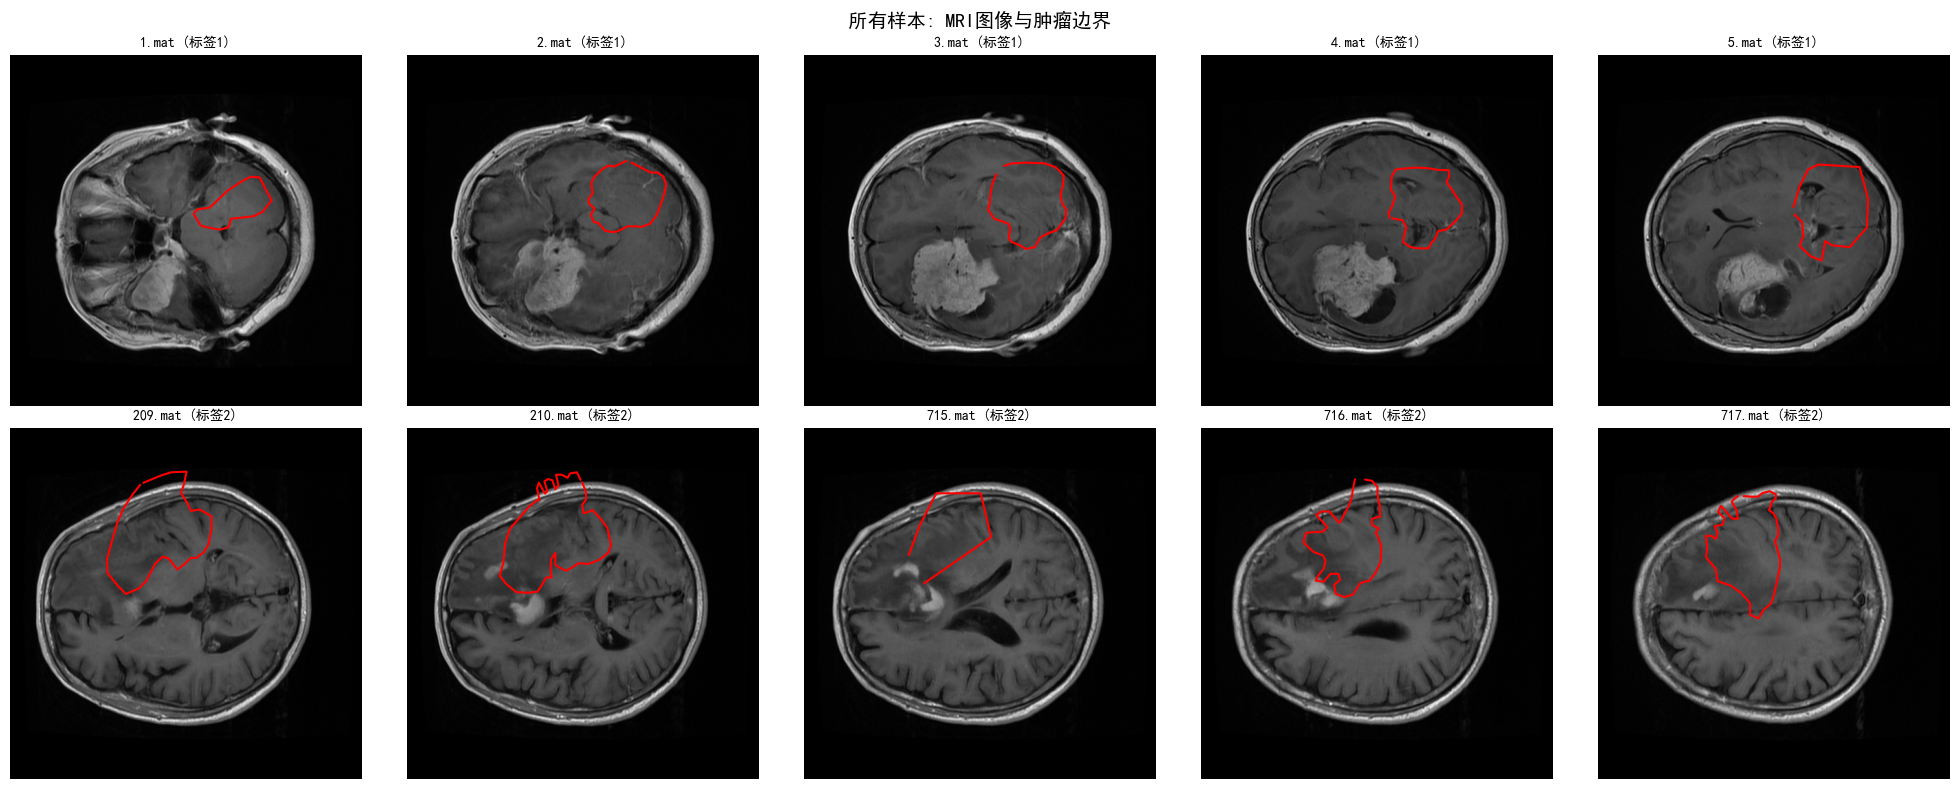

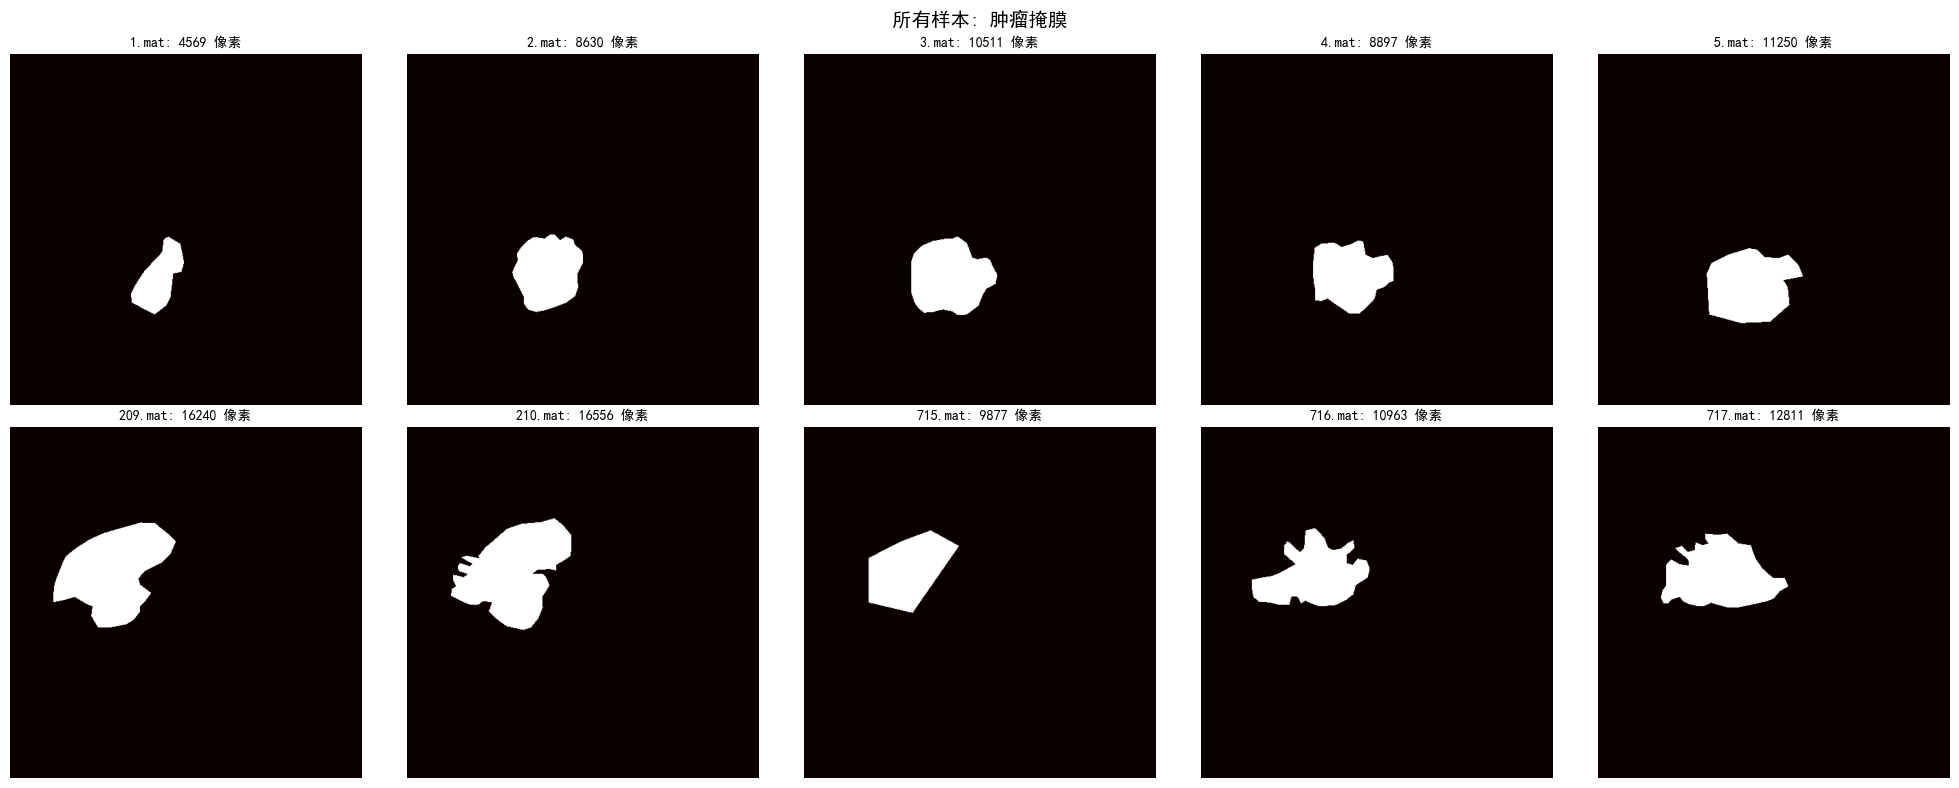

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, fname in enumerate(data_files):
    d = all_data[fname]
    ax = axes[idx]
    # 显示原始图像
    ax.imshow(d['image'], cmap='gray')
    # 叠加肿瘤边界
    border = d['border']
    if border.shape[0] > 2:
        ax.plot(border[:, 0], border[:, 1], 'r-', linewidth=1.5)
    ax.set_title(f"{fname} (标签{int(d['label'])})", fontsize=10)
    ax.axis('off')

plt.suptitle('所有样本: MRI图像与肿瘤边界', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 显示掩膜
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for idx, fname in enumerate(data_files):
    d = all_data[fname]
    axes[idx].imshow(d['mask'], cmap='hot')
    axes[idx].set_title(f"{fname}: {d['mask'].sum()} 像素", fontsize=10)
    axes[idx].axis('off')
plt.suptitle('所有样本: 肿瘤掩膜', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 项目1
### 原理
傅里叶描述子将闭合轮廓表示为复数信号 $z(k) = x(k) + j y(k)$,然后通过FFT将其变换到频域。通过保留不同数量的低频描述子 $P$,可以实现不同程度的形状近似。
- **P 小:** 近似轮廓平滑,仅保留整体形状,细节丢失
- **P 大:** 更精确地重建原始形状,包括细节
- **P = N:** 完美重建原始轮廓
### 步骤
1. 从肿瘤掩膜提取闭合边界
2. 将边界表示为复数序列
3. FFT得到傅里叶描述子
4. 截断到 P 个描述子并 IFFT 重建

### 1.1 边界提取与傅里叶描述子计算

样本 1.mat: 边界点数 N = 262
傅里叶描述子数量 = 262
DC分量 |FD[0]| = 102540.44 (质心)
前5个描述子的幅度: [102540.44158282   3434.45393012    651.92627369    607.40388278
    176.04594721]


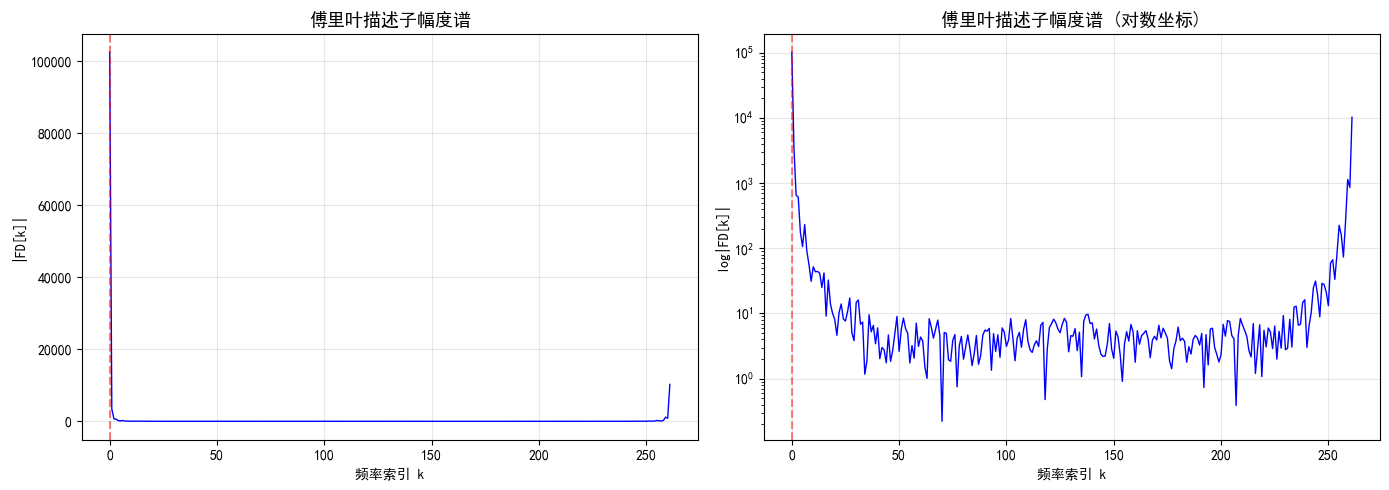


观察: 幅度谱随频率迅速衰减,表明低频分量主导形状信息。
这意味着用少量低频描述子即可捕获形状的主要特征。


In [3]:
def extract_boundary_from_mask(mask):
    """从二值掩膜中提取最长闭合轮廓"""
    contours, hierarchy = cv2.findContours(
        mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )
    if not contours:
        return None
    # 选择最长的轮廓
    longest = max(contours, key=lambda c: c.shape[0])
    # 去除冗余维度: (N, 1, 2) -> (N, 2)
    boundary = longest.squeeze()
    return boundary

def boundary_to_complex(boundary):
    """将边界点 (x, y) 转换为复数序列 z = x + j*y"""
    return boundary[:, 0].astype(np.float64) + 1j * boundary[:, 1].astype(np.float64)

def compute_fourier_descriptors(z):
    """计算傅里叶描述子 (FFT)"""
    return np.fft.fft(z)

def reconstruct_boundary(descriptors, P):
    """
    使用前P个低频描述子重建边界。
    P 应小于 len(descriptors)。
    策略: 保留 [0, P//2] 和 [-(P-1)//2, -1] 范围的描述子(低频对称截断)
    """
    N = len(descriptors)
    fd = np.zeros(N, dtype=np.complex128)
    # 保留低频分量: 正频率 [0, half] + 负频率 [-(P-half-1), -1]
    half = P // 2
    fd[:half+1] = descriptors[:half+1]
    tail = P - half - 1  # 需要保留的负频率数量
    if tail > 0:
        fd[-tail:] = descriptors[-tail:]
    # 特殊情况: 如果只有DC分量(此时half=0, tail=0)
    if P == 1:
        fd[0] = descriptors[0]
    z_recon = np.fft.ifft(fd)
    return np.real(z_recon), np.imag(z_recon)

def compute_reconstruction_error(original_z, reconstructed_z):
    """计算重建误差(欧几里得距离的均方根)"""
    diff = np.abs(original_z - reconstructed_z)
    return np.sqrt(np.mean(diff**2))

# 选择一个样本进行详细分析
sample_fname = '1.mat'
sample = all_data[sample_fname]
boundary = extract_boundary_from_mask(sample['mask'])
z = boundary_to_complex(boundary)
fd = compute_fourier_descriptors(z)
N = len(z)

print(f"样本 {sample_fname}: 边界点数 N = {N}")
print(f"傅里叶描述子数量 = {len(fd)}")
print(f"DC分量 |FD[0]| = {np.abs(fd[0]):.2f} (质心)")
print(f"前5个描述子的幅度: {np.abs(fd[:5])}")

# 显示傅里叶描述子频谱
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(np.abs(fd), 'b-', linewidth=1)
axes[0].set_title('傅里叶描述子幅度谱', fontsize=13)
axes[0].set_xlabel('频率索引 k')
axes[0].set_ylabel('|FD[k]|')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=0, color='r', linestyle='--', alpha=0.5, label='DC')

axes[1].semilogy(np.abs(fd), 'b-', linewidth=1)
axes[1].set_title('傅里叶描述子幅度谱 (对数坐标)', fontsize=13)
axes[1].set_xlabel('频率索引 k')
axes[1].set_ylabel('log|FD[k]|')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(x=0, color='r', linestyle='--', alpha=0.5, label='DC')
plt.tight_layout()
plt.show()

print("\n观察: 幅度谱随频率迅速衰减,表明低频分量主导形状信息。")
print("这意味着用少量低频描述子即可捕获形状的主要特征。")

### 1.2 逐步增加描述子数量 P,观察形状变化

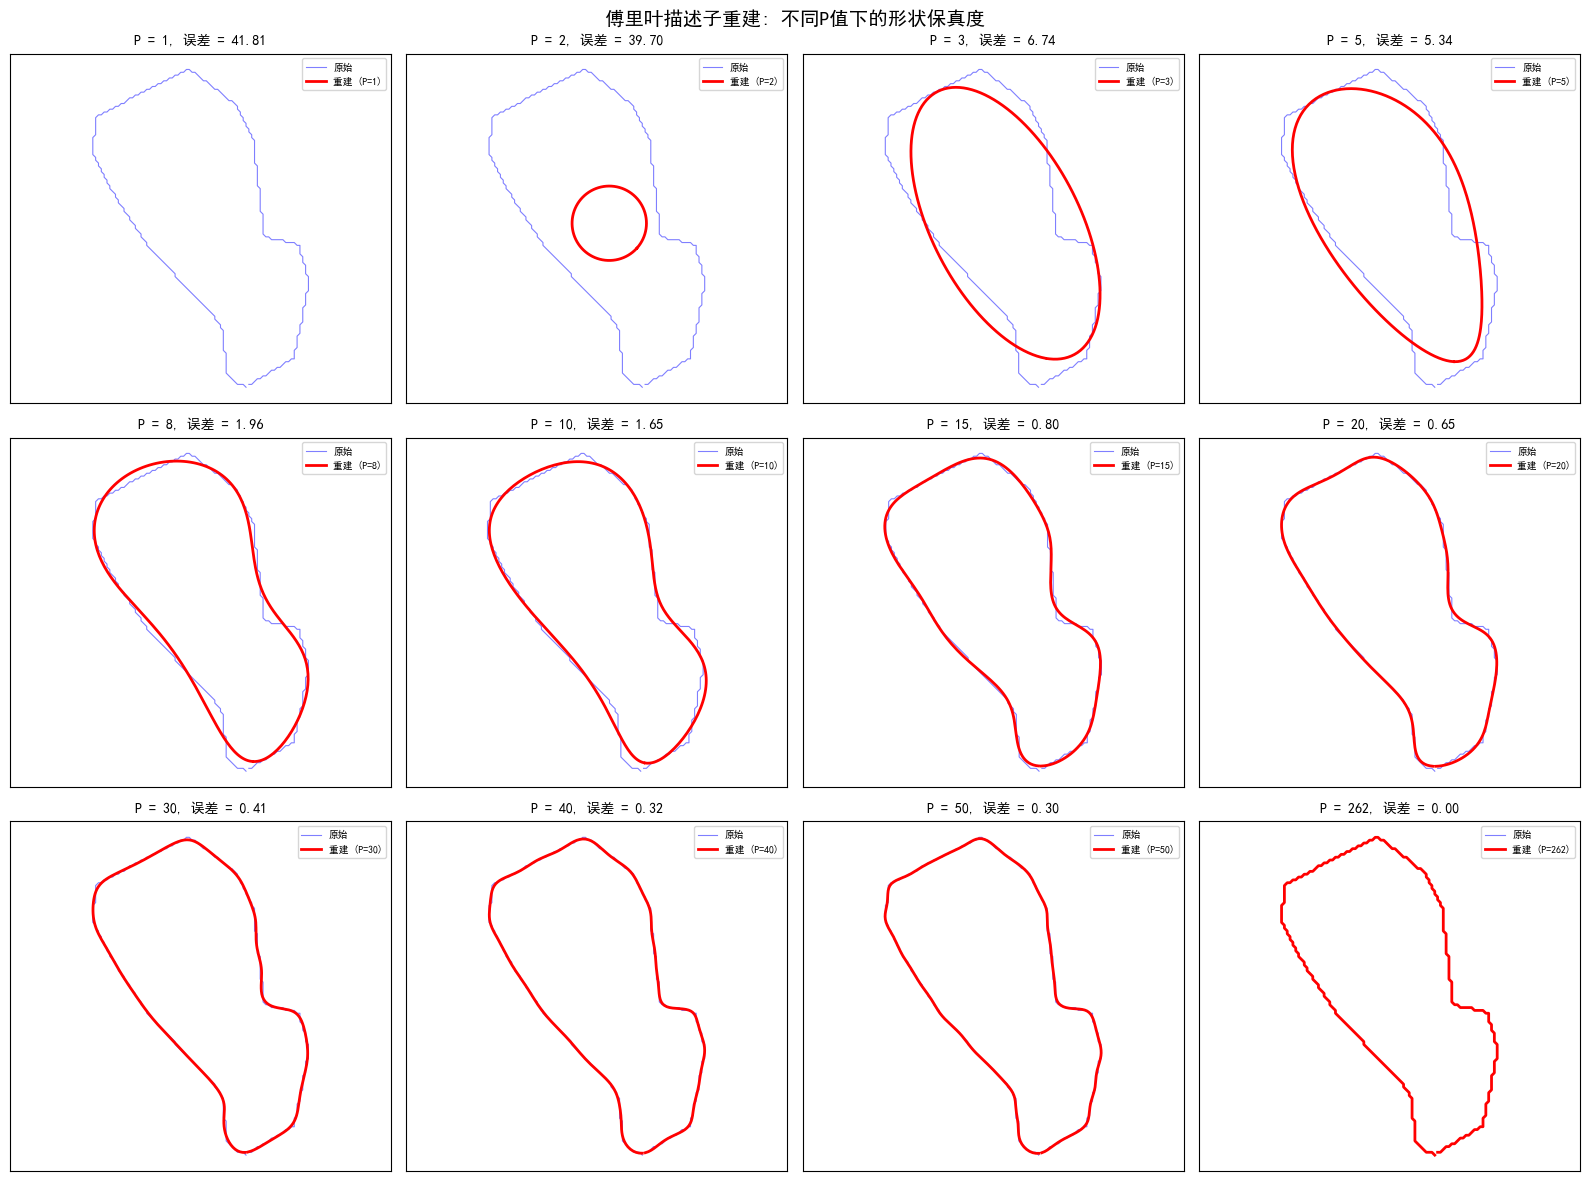

In [4]:
# 测试不同的 P 值
P_values = [1, 2, 3, 5, 8, 10, 15, 20, 30, 40, 50, N]
errors = []

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, P in enumerate(P_values):
    if P > N:
        P = N
    ax = axes[idx]

    # 重建
    x_recon, y_recon = reconstruct_boundary(fd, P)
    z_recon = x_recon + 1j * y_recon
    err = compute_reconstruction_error(z, z_recon)
    errors.append(err)

    # 绘制
    ax.plot(boundary[:, 0], boundary[:, 1], 'b-', linewidth=0.8, alpha=0.5, label='原始')
    ax.plot(x_recon, y_recon, 'r-', linewidth=2, label=f'重建 (P={P})')
    ax.set_title(f'P = {P}, 误差 = {err:.2f}', fontsize=10)
    ax.axis('equal')
    ax.legend(fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('傅里叶描述子重建: 不同P值下的形状保真度', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.3 重建误差 vs 描述子数量 P

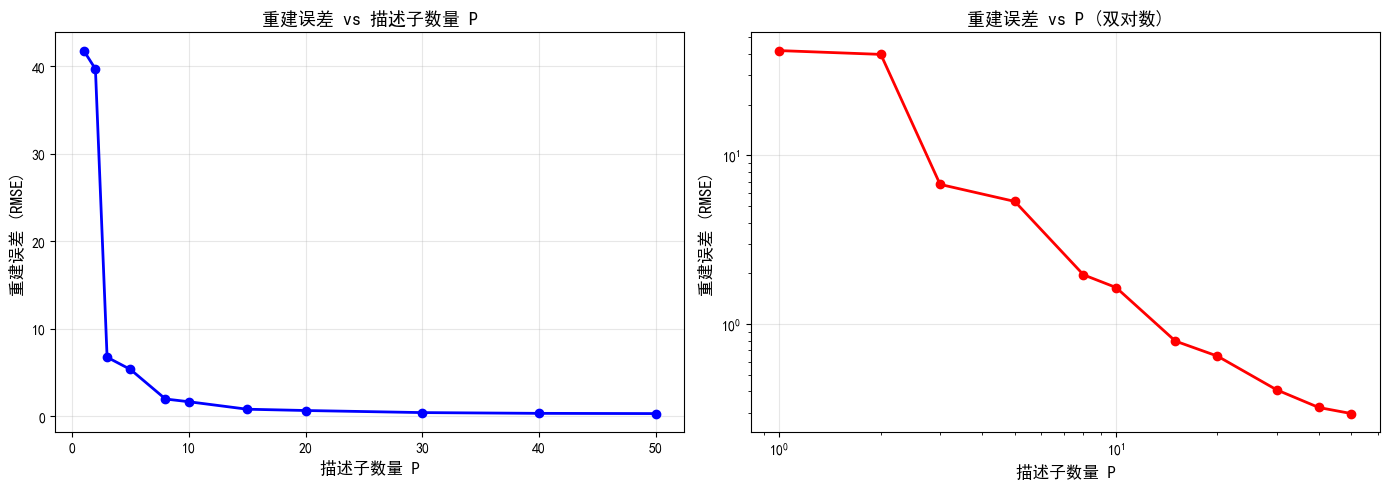

关键观察:
  P=1  (仅质心):    误差 = 41.81
  P=5  (粗糙近似):  误差 = 5.34
  P=10 (基本形状):  误差 = 1.65
  P=20 (良好近似):  误差 = 0.65
  P=50 (精细重建):  误差 = 0.32
  P=N  (完美重建):  误差 ~ 0

  误差降至初始的 10% 需要 P ~ 8
  误差降至初始的 5% 需要 P ~ 8
  误差降至初始的 1% 需要 P ~ 30


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 线性坐标
axes[0].plot(P_values[:-1], errors[:-1], 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('描述子数量 P', fontsize=12)
axes[0].set_ylabel('重建误差 (RMSE)', fontsize=12)
axes[0].set_title('重建误差 vs 描述子数量 P', fontsize=13)
axes[0].grid(True, alpha=0.3)

# 双对数坐标
axes[1].loglog(P_values[:-1], errors[:-1], 'ro-', linewidth=2, markersize=6)
axes[1].set_xlabel('描述子数量 P', fontsize=12)
axes[1].set_ylabel('重建误差 (RMSE)', fontsize=12)
axes[1].set_title('重建误差 vs P (双对数)', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 关键观察点
print("=" * 60)
print("关键观察:")
print(f"  P=1  (仅质心):    误差 = {errors[0]:.2f}")
print(f"  P=5  (粗糙近似):  误差 = {errors[3]:.2f}")
print(f"  P=10 (基本形状):  误差 = {errors[5]:.2f}")
print(f"  P=20 (良好近似):  误差 = {errors[7]:.2f}")
print(f"  P=50 (精细重建):  误差 = {errors[9]:.2f}")
print(f"  P=N  (完美重建):  误差 ~ 0")
print()
# 计算误差下降到一定比例所需的 P
for threshold in [0.1, 0.05, 0.01]:
    target = threshold * errors[0]
    for p_val, err in zip(P_values, errors):
        if err <= target:
            print(f"  误差降至初始的 {threshold*100:.0f}% 需要 P ~ {p_val}")
            break
print("=" * 60)

### 1.4 多个样本的傅里叶描述子分析

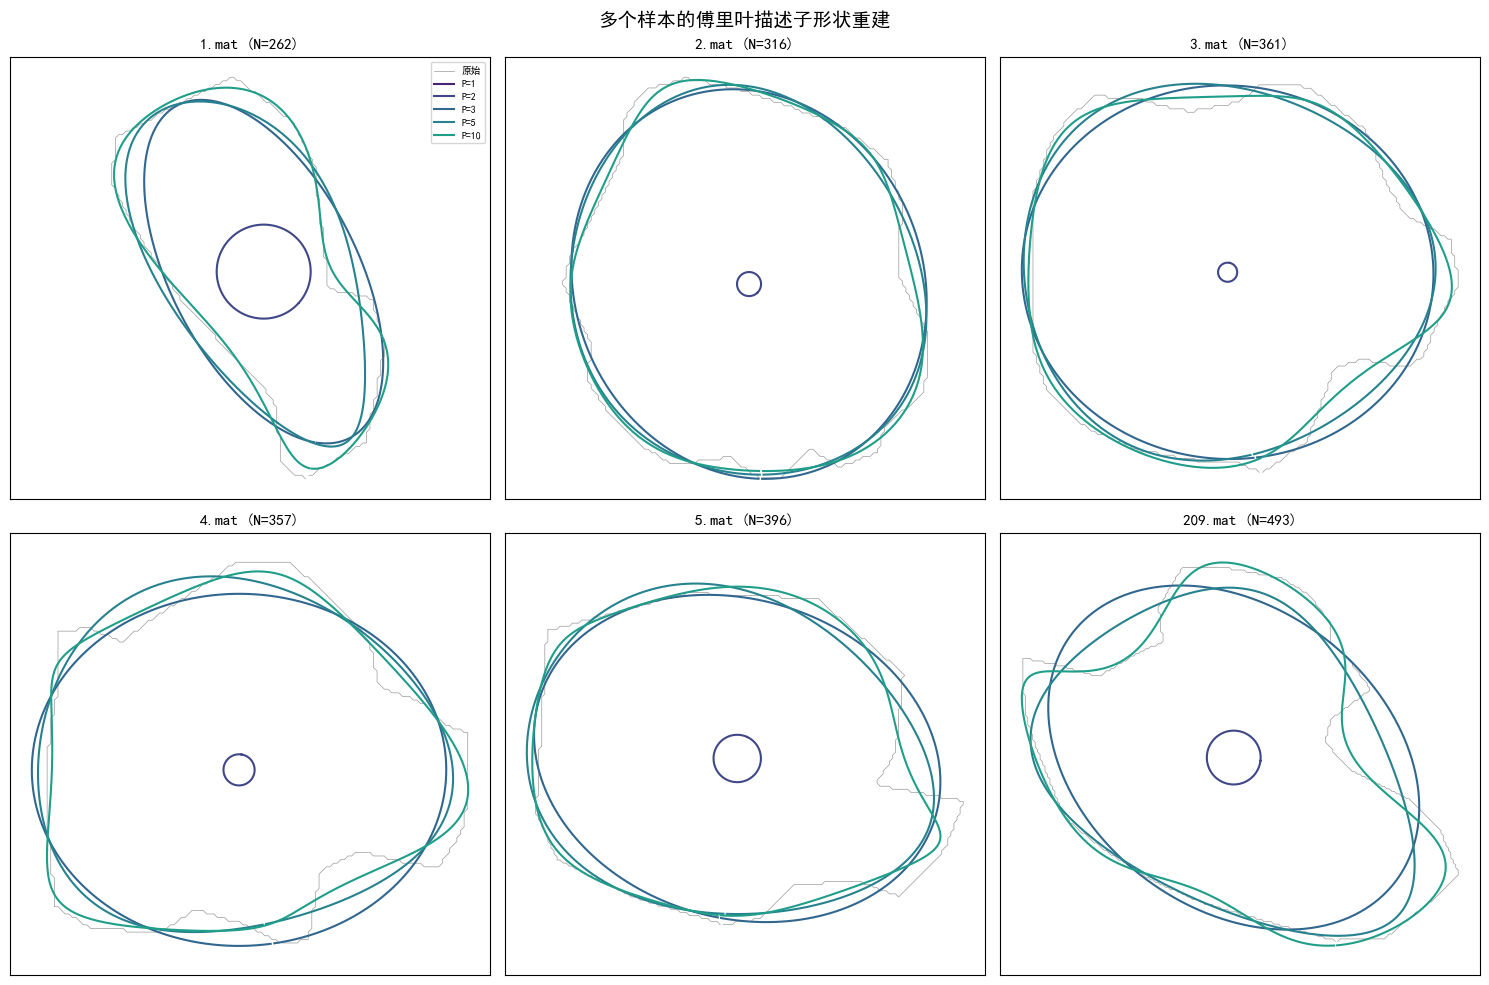

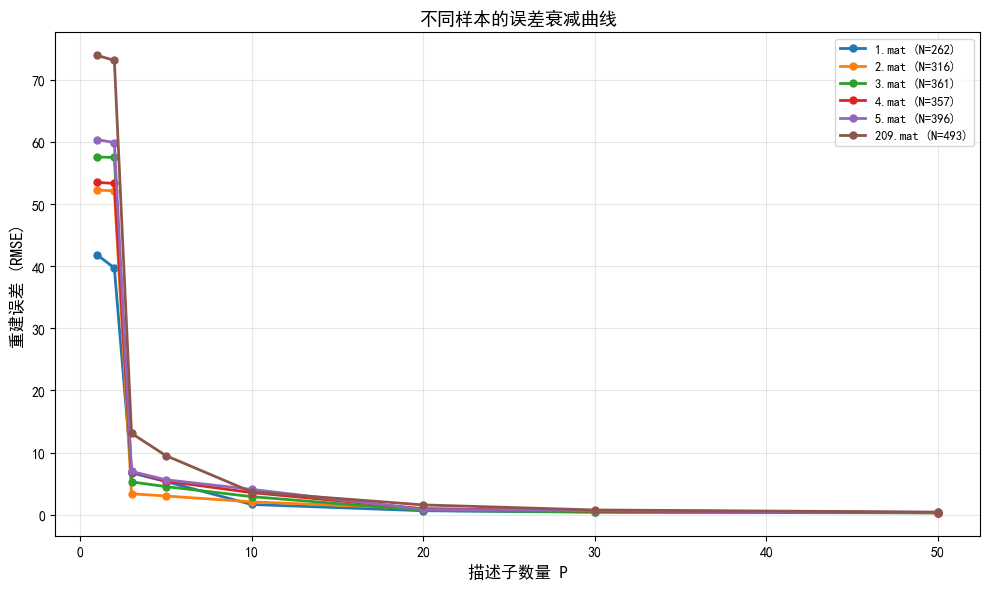


观察: 不同样本的误差衰减速率不同,但与肿瘤轮廓的复杂度相关。
更复杂的形状需要更多的描述子才能达到相同的重建精度。


In [6]:
# 对所有样本计算傅里叶描述子并比较
sample_names = data_files[:6]  # 选择6个样本
P_test = [1, 2, 3, 5, 10, 20, 30, 50]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

all_errors = {}

for idx, fname in enumerate(sample_names):
    d = all_data[fname]
    boundary = extract_boundary_from_mask(d['mask'])
    z = boundary_to_complex(boundary)
    fd = compute_fourier_descriptors(z)
    N_pts = len(z)

    ax = axes[idx]

    # 绘制原始边界
    ax.plot(boundary[:, 0], boundary[:, 1], 'k-', linewidth=0.5, alpha=0.4, label='原始')

    # 对每个P值重建
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(P_test)))
    sample_errors = []
    for p_idx, P in enumerate(P_test):
        if P >= N_pts:
            P = N_pts
        x_r, y_r = reconstruct_boundary(fd, P)
        z_r = x_r + 1j * y_r
        err = compute_reconstruction_error(z, z_r)
        sample_errors.append(err)
        if p_idx < 5:  # 只显示部分
            ax.plot(x_r, y_r, '-', color=colors[p_idx], linewidth=1.5,
                   label=f'P={P}' if idx == 0 else None)

    all_errors[fname] = sample_errors
    ax.set_title(f'{fname} (N={N_pts})', fontsize=11)
    ax.axis('equal')
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].legend(fontsize=7, loc='best')
plt.suptitle('多个样本的傅里叶描述子形状重建', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 比较误差曲线
fig, ax = plt.subplots(figsize=(10, 6))
for fname in sample_names:
    n_pts = len(extract_boundary_from_mask(all_data[fname]['mask']))
    ax.plot(P_test[:len(all_errors[fname])], all_errors[fname],
            'o-', linewidth=2, markersize=5, label=f'{fname} (N={n_pts})')

ax.set_xlabel('描述子数量 P', fontsize=12)
ax.set_ylabel('重建误差 (RMSE)', fontsize=12)
ax.set_title('不同样本的误差衰减曲线', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n观察: 不同样本的误差衰减速率不同,但与肿瘤轮廓的复杂度相关。")
print("更复杂的形状需要更多的描述子才能达到相同的重建精度。")

### 讨论

**描述子数量 P 与形状保真度之间的关系:**

1. **P 很小时(1-3):** 仅能重建肿瘤的大致位置和基本椭圆形状。P=1 只给出质心位置。

2. **P 中等时(5-15):** 能够重建肿瘤的主要形状特征,如整体大小、方向、大致轮廓。

3. **P 较大时(20-50):** 形状细节逐渐恢复,包括不规则边界、凸起和凹陷。

4. **误差衰减呈幂律关系:** 在对数坐标中误差近似线性下降,表明傅里叶描述子具有高效的能量集中特性 — 少量低频系数包含了形状的大部分信息。

5. **形状复杂度影响:** 边界更曲折的肿瘤需要更多描述子达到相同精度。傅里叶描述子对光滑形状的表示效率更高。

6. **实际意义:** 傅里叶描述子可用于肿瘤形状分类 — 恶性肿瘤通常具有更不规则(更高频分量更多)的边界。

# 项目2: 一阶统计特征
### 原理

一阶统计特征基于图像灰度直方图 $p(r)$,描述像素强度的分布特性:

- **均值 (Mean):** $\mu = \sum_{r} r \cdot p(r)$ — 平均亮度
- **方差 (Variance):** $\sigma^2 = \sum_{r} (r-\mu)^2 \cdot p(r)$ — 对比度/分散程度
- **一致性 (Uniformity):** $U = \sum_{r} p(r)^2$ — 灰度分布的均匀程度
- **熵 (Entropy):** $E = -\sum_{r} p(r) \log_2 p(r)$ — 信息量/复杂度

### 3x3 均值滤波

迭代应用均值滤波器会渐进逼近高斯模糊(中心极限定理)。每次迭代:
$$I_{t+1}(x,y) = \frac{1}{9}\sum_{i=-1}^{1}\sum_{j=-1}^{1} I_t(x+i, y+j)$$

### 步骤
1. 计算肿瘤质心确定ROI
2. 提取ROI像素并计算直方图特征
3. 迭代应用3x3均值滤波
4. 记录统计指标的动态变化

### 2.1 肿瘤质心计算与ROI提取

样本 1.mat:
  肿瘤质心: (216.2, 327.6)
  ROI像素数量: 4569
  ROI像素值范围: [159, 2572]


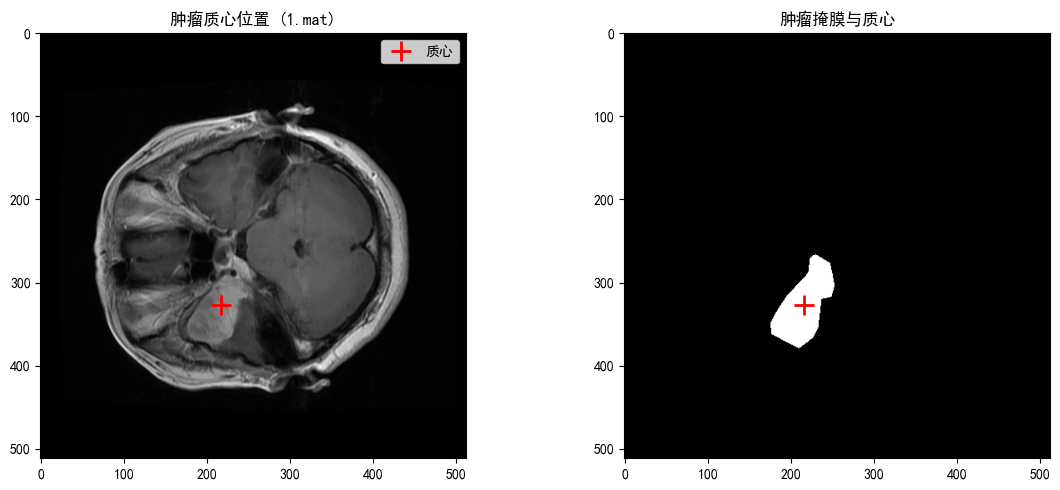

In [7]:
def compute_centroid(mask):
    """计算二值掩膜的质心坐标"""
    y_indices, x_indices = np.where(mask > 0)
    if len(x_indices) == 0:
        return 0, 0
    cx = np.mean(x_indices)
    cy = np.mean(y_indices)
    return cx, cy

def extract_roi_pixels(image, mask):
    """提取ROI(肿瘤区域)内的所有像素值"""
    roi_pixels = image[mask > 0]
    return roi_pixels

# 计算所有样本的质心并可视化
sample_fname = '1.mat'
d = all_data[sample_fname]
cx, cy = compute_centroid(d['mask'])
roi_pixels = extract_roi_pixels(d['image'], d['mask'])

print(f"样本 {sample_fname}:")
print(f"  肿瘤质心: ({cx:.1f}, {cy:.1f})")
print(f"  ROI像素数量: {len(roi_pixels)}")
print(f"  ROI像素值范围: [{roi_pixels.min():.0f}, {roi_pixels.max():.0f}]")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(d['image'], cmap='gray')
axes[0].plot(cx, cy, 'r+', markersize=15, markeredgewidth=2, label='质心')
axes[0].set_title(f'肿瘤质心位置 ({sample_fname})', fontsize=12)
axes[0].legend()

axes[1].imshow(d['mask'], cmap='gray')
axes[1].plot(cx, cy, 'r+', markersize=15, markeredgewidth=2)
axes[1].set_title('肿瘤掩膜与质心', fontsize=12)

plt.tight_layout()
plt.show()

### 2.2 一阶直方图特征计算

样本                 均值         方差        一致性          熵
----------------------------------------------------------------------
1.mat          1516.9    99152.4     0.0095     6.9763
2.mat          1436.7    92731.1     0.0072     7.2994
3.mat          1529.4    82756.9     0.0093     7.0273
4.mat          1601.0    91356.1     0.0082     7.2484
5.mat          1167.1   315834.3     0.0053     7.6891
209.mat        1104.7    34730.3     0.0133     6.6130
210.mat        1148.4   122339.9     0.0146     6.5805
715.mat        1078.3    86617.3     0.0129     6.7422
716.mat        1079.0   146142.6     0.0132     6.7875
717.mat         997.9    41477.2     0.0120     6.7175


C:\Users\26971\AppData\Local\Temp\ipykernel_36732\3065194687.py:64: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
d:\coding\DIP_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


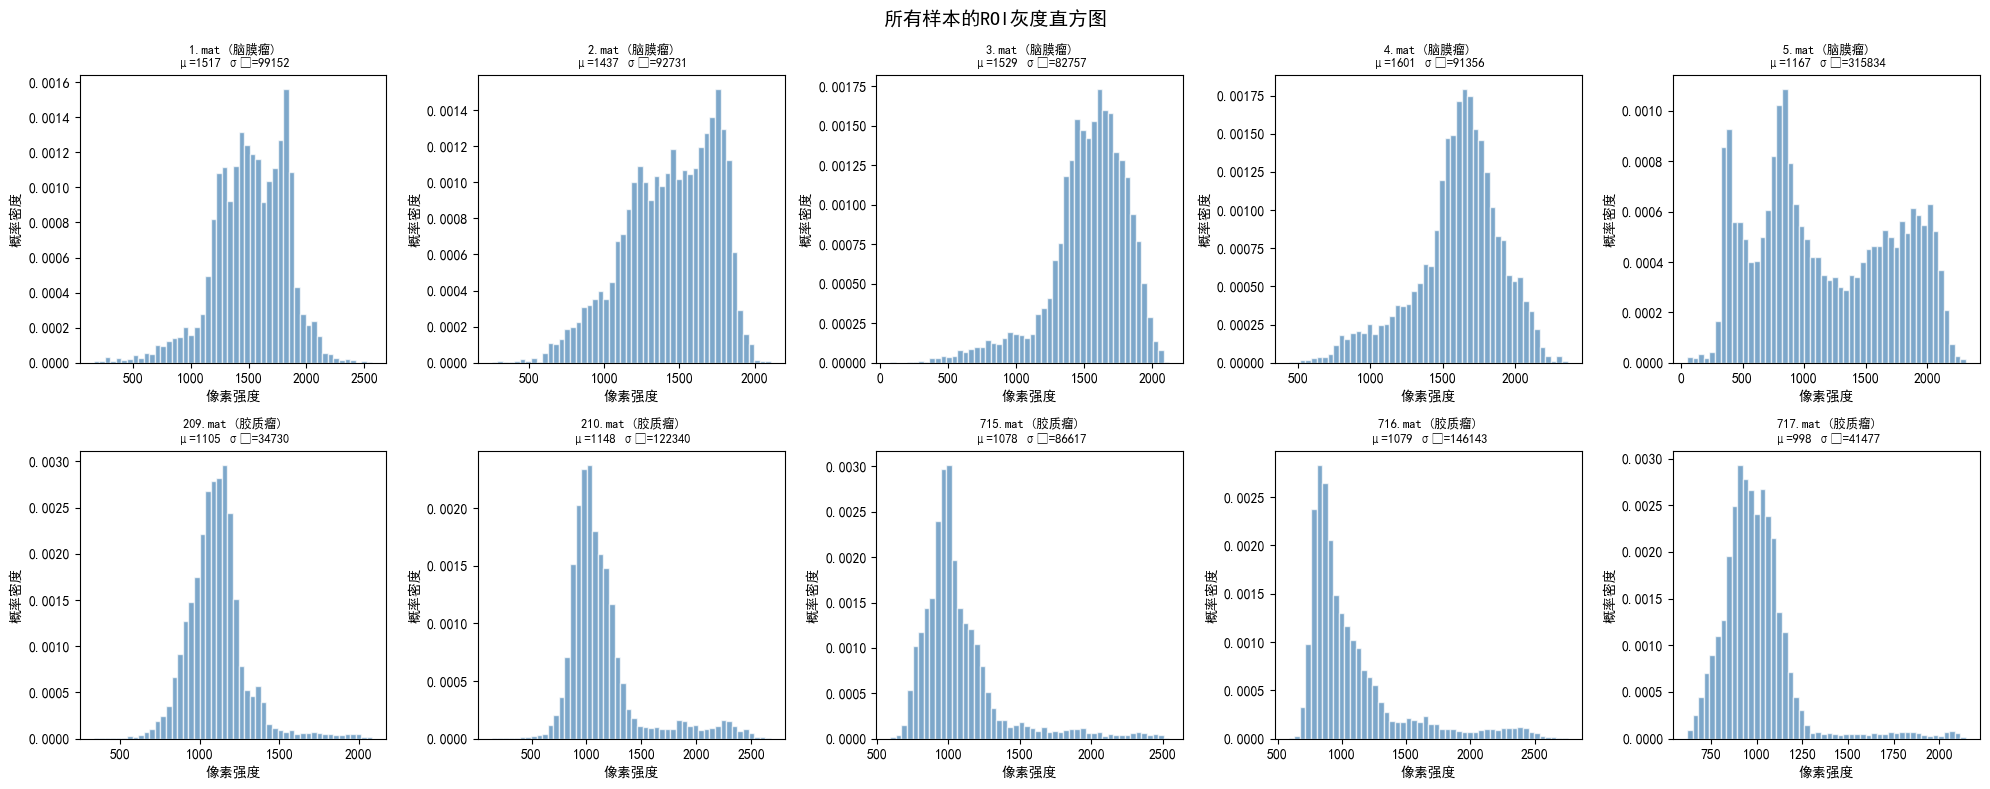


初步观察:
- 脑膜瘤(标签1)和胶质瘤(标签2)的直方图特征可能存在差异
- 方差大的样本灰度分布更分散,对应更不均匀的组织
- 熵值高表示纹理信息更丰富


In [8]:
def compute_histogram_features(pixels, bins=256):
    """
    计算一阶直方图特征。

    参数:
        pixels: 像素值数组
        bins: 直方图bins数量

    返回:
        mean, variance, uniformity, entropy
    """
    # 计算归一化直方图
    hist, bin_edges = np.histogram(pixels, bins=bins, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 均值
    mean = np.sum(bin_centers * hist * (bin_edges[1] - bin_edges[0]))
    # 更精确: 直接用像素计算
    mean = np.mean(pixels)

    # 方差
    variance = np.var(pixels)

    # 一致性 (Uniformity) — 也称为能量(Energy)
    # U = sum(p(r)^2) * bin_width 近似
    hist_counts, _ = np.histogram(pixels, bins=bins)
    p = hist_counts / hist_counts.sum()
    uniformity = np.sum(p ** 2)

    # 熵 (Entropy)
    # E = -sum(p(r) * log2(p(r)))
    # 避免 log(0)
    p_nonzero = p[p > 0]
    entropy = -np.sum(p_nonzero * np.log2(p_nonzero))

    return mean, variance, uniformity, entropy

# 对所有样本计算一阶统计特征
print("=" * 70)
print(f"{"样本":<10} {"均值":>10} {"方差":>10} {"一致性":>10} {"熵":>10}")
print("-" * 70)
for fname in data_files:
    d = all_data[fname]
    roi = extract_roi_pixels(d['image'], d['mask'])
    m, v, u, e = compute_histogram_features(roi)
    print(f"{fname:<10} {m:>10.1f} {v:>10.1f} {u:>10.4f} {e:>10.4f}")

# 可视化所有样本的ROI直方图
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for idx, fname in enumerate(data_files):
    d = all_data[fname]
    roi = extract_roi_pixels(d['image'], d['mask'])
    ax = axes[idx]
    ax.hist(roi, bins=50, density=True, color='steelblue', alpha=0.7, edgecolor='white')
    m, v, u, e = compute_histogram_features(roi)
    label_name = "脑膜瘤" if d["label"] == 1 else "胶质瘤"
    ax.set_title(f'{fname} ({label_name})\nμ={m:.0f} σ²={v:.0f}', fontsize=9)
    ax.set_xlabel('像素强度')
    ax.set_ylabel('概率密度')

plt.suptitle('所有样本的ROI灰度直方图', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n初步观察:")
print("- 脑膜瘤(标签1)和胶质瘤(标签2)的直方图特征可能存在差异")
print("- 方差大的样本灰度分布更分散,对应更不均匀的组织")
print("- 熵值高表示纹理信息更丰富")

### 2.3 迭代3x3均值滤波 — 模拟渐进高斯模糊

In [9]:
def mean_filter_3x3(image):
    """3x3均值滤波 (单次迭代)"""
    kernel = np.ones((3, 3)) / 9.0
    return ndimage.convolve(image, kernel, mode='reflect')

def iterative_mean_filter(image, max_iterations=50):
    """
    迭代应用3x3均值滤波,记录每次迭代后的统计特征。
    对ROI区域单独进行滤波。
    """
    # 只对ROI区域操作
    filtered = image.copy()

    stats_history = {
        'iteration': [],
        'mean': [],
        'variance': [],
        'uniformity': [],
        'entropy': []
    }

    # 初始状态 (iter=0)
    m, v, u, e = compute_histogram_features(filtered)
    stats_history['iteration'].append(0)
    stats_history['mean'].append(m)
    stats_history['variance'].append(v)
    stats_history['uniformity'].append(u)
    stats_history['entropy'].append(e)

    for t in range(1, max_iterations + 1):
        filtered = mean_filter_3x3(filtered)
        m, v, u, e = compute_histogram_features(filtered)
        stats_history['iteration'].append(t)
        stats_history['mean'].append(m)
        stats_history['variance'].append(v)
        stats_history['uniformity'].append(u)
        stats_history['entropy'].append(e)

    return filtered, stats_history

# 选择样本进行分析
sample_fname = '1.mat'
d = all_data[sample_fname]
roi = extract_roi_pixels(d['image'], d['mask'])

# 对整个图像中ROI区域进行迭代滤波
# 为便于计算,使用完整图像但只统计ROI区域
filtered_image, stats = iterative_mean_filter(d['image'], max_iterations=30)

# 提取每次迭代后ROI的统计
roi_stats = {'iteration': [], 'mean': [], 'variance': [], 'uniformity': [], 'entropy': []}
current_img = d['image'].copy()
for t in range(31):
    roi_pix = current_img[d['mask'] > 0]
    m, v, u, e = compute_histogram_features(roi_pix)
    roi_stats['iteration'].append(t)
    roi_stats['mean'].append(m)
    roi_stats['variance'].append(v)
    roi_stats['uniformity'].append(u)
    roi_stats['entropy'].append(e)
    if t < 30:
        current_img = mean_filter_3x3(current_img)

print(f"样本 {sample_fname} — 迭代均值滤波统计:")
print(f"{"迭代":<8} {"均值":>10} {"方差":>10} {"一致性":>10} {"熵":>10}")
print("-" * 55)
for i in [0, 1, 2, 3, 5, 10, 20, 30]:
    print(f"{roi_stats["iteration"][i]:<8} "
          f"{roi_stats["mean"][i]:>10.1f} "
          f"{roi_stats["variance"][i]:>10.1f} "
          f"{roi_stats["uniformity"][i]:>10.4f} "
          f"{roi_stats["entropy"][i]:>10.4f}")

样本 1.mat — 迭代均值滤波统计:
迭代               均值         方差        一致性          熵
-------------------------------------------------------
0            1516.9    99152.4     0.0095     6.9763
1            1514.3    90387.5     0.0087     7.0831
2            1511.7    84798.4     0.0082     7.1543
3            1509.2    80652.2     0.0079     7.2116
5            1504.5    74600.3     0.0072     7.3305
10           1494.5    65351.6     0.0062     7.5299
20           1478.3    55717.8     0.0055     7.6381
30           1465.1    50191.3     0.0051     7.7197


### 2.4 统计指标动态变化可视化

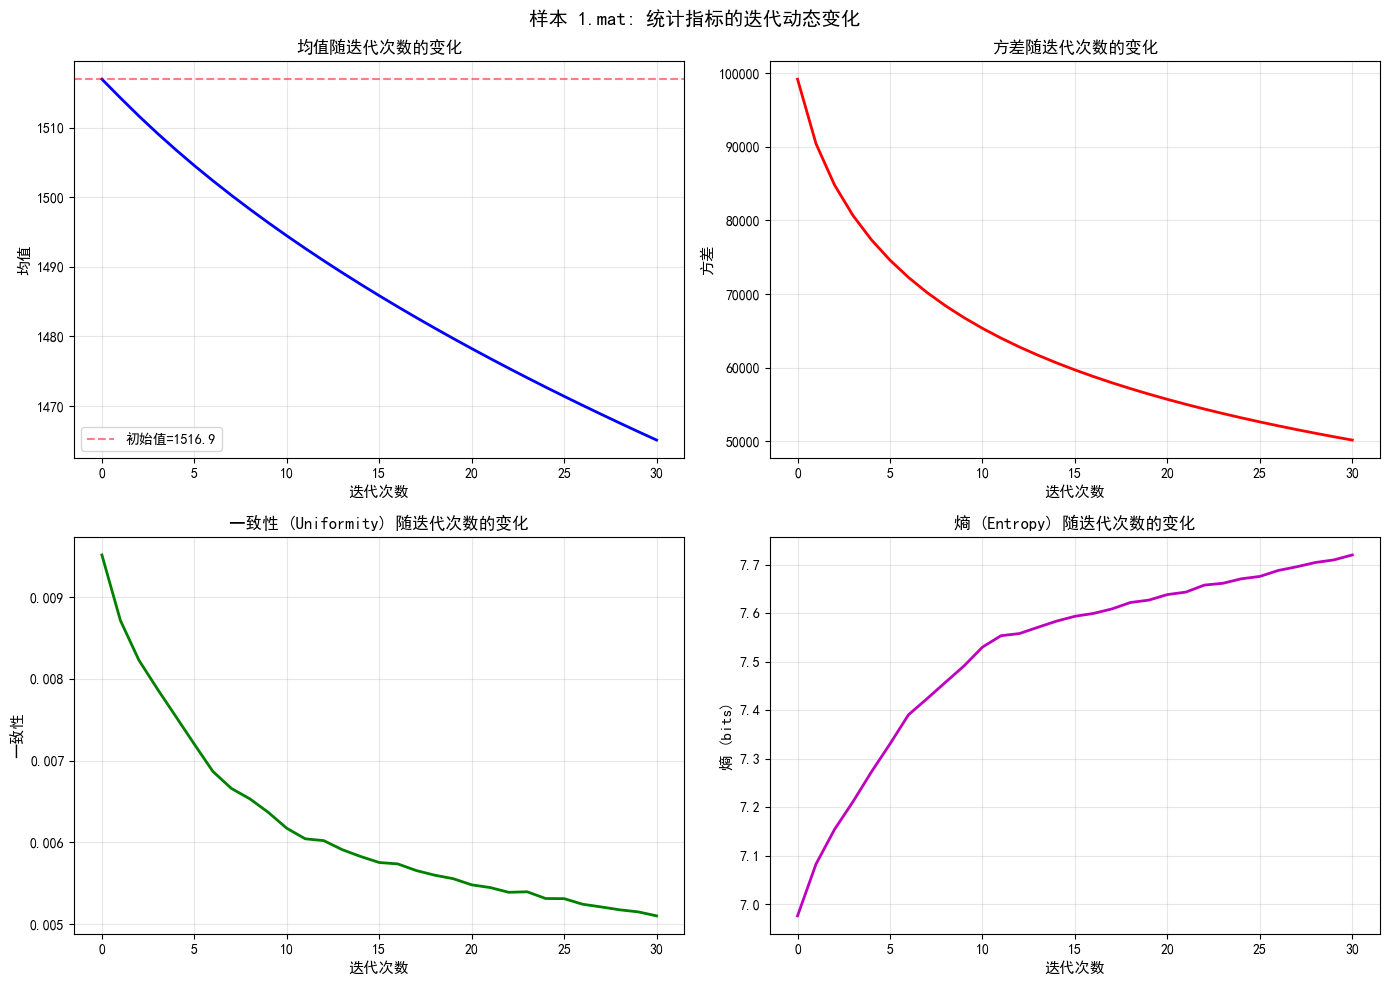

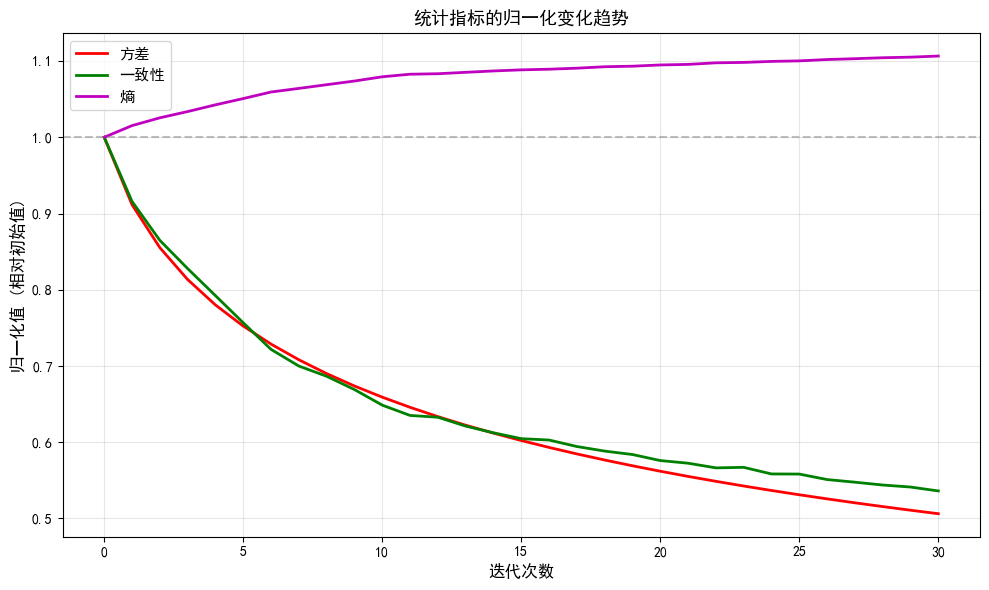

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 均值变化
axes[0, 0].plot(roi_stats['iteration'], roi_stats['mean'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('迭代次数', fontsize=11)
axes[0, 0].set_ylabel('均值', fontsize=11)
axes[0, 0].set_title('均值随迭代次数的变化', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=roi_stats['mean'][0], color='r', linestyle='--',
                   alpha=0.5, label=f'初始值={roi_stats["mean"][0]:.1f}')
axes[0, 0].legend()

# 方差变化
axes[0, 1].plot(roi_stats['iteration'], roi_stats['variance'], 'r-', linewidth=2)
axes[0, 1].set_xlabel('迭代次数', fontsize=11)
axes[0, 1].set_ylabel('方差', fontsize=11)
axes[0, 1].set_title('方差随迭代次数的变化', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# 一致性变化
axes[1, 0].plot(roi_stats['iteration'], roi_stats['uniformity'], 'g-', linewidth=2)
axes[1, 0].set_xlabel('迭代次数', fontsize=11)
axes[1, 0].set_ylabel('一致性', fontsize=11)
axes[1, 0].set_title('一致性 (Uniformity) 随迭代次数的变化', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# 熵变化
axes[1, 1].plot(roi_stats['iteration'], roi_stats['entropy'], 'm-', linewidth=2)
axes[1, 1].set_xlabel('迭代次数', fontsize=11)
axes[1, 1].set_ylabel('熵 (bits)', fontsize=11)
axes[1, 1].set_title('熵 (Entropy) 随迭代次数的变化', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'样本 {sample_fname}: 统计指标的迭代动态变化', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 归一化的变化率比较
fig, ax = plt.subplots(figsize=(10, 6))
for key, color, label in [
    ('variance', 'r', '方差'),
    ('uniformity', 'g', '一致性'),
    ('entropy', 'm', '熵')
]:
    values = np.array(roi_stats[key])
    normalized = values / values[0]  # 归一化到初始值
    ax.plot(roi_stats['iteration'], normalized, '-', color=color, linewidth=2, label=label)

ax.set_xlabel('迭代次数', fontsize=12)
ax.set_ylabel('归一化值 (相对初始值)', fontsize=12)
ax.set_title('统计指标的归一化变化趋势', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 2.5 滤波效果的视觉展示

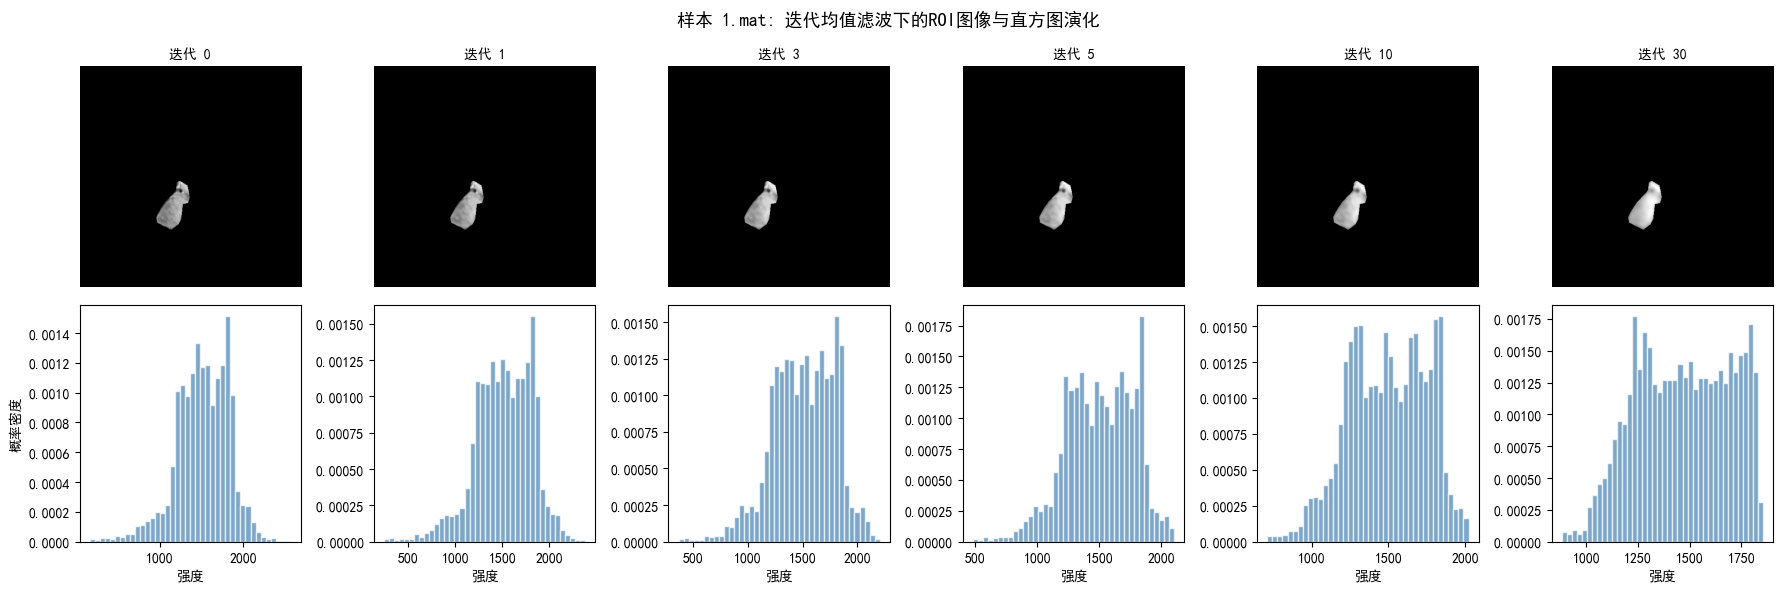

In [11]:
# 显示不同迭代次数下的ROI图像和直方图
iterations_to_show = [0, 1, 3, 5, 10, 30]
sample_fname = '1.mat'
d = all_data[sample_fname]

fig, axes = plt.subplots(2, len(iterations_to_show), figsize=(18, 6))

current_img = d['image'].copy()
for idx, t in enumerate(range(max(iterations_to_show) + 1)):
    if t in iterations_to_show:
        col_idx = iterations_to_show.index(t)
        # 显示ROI区域
        roi_display = current_img.copy()
        roi_display[d['mask'] == 0] = 0

        axes[0, col_idx].imshow(roi_display, cmap='gray')
        axes[0, col_idx].set_title(f'迭代 {t}', fontsize=10)
        axes[0, col_idx].axis('off')

        # 显示直方图
        roi_pix = current_img[d['mask'] > 0]
        axes[1, col_idx].hist(roi_pix, bins=40, density=True,
                              color='steelblue', alpha=0.7, edgecolor='white')
        axes[1, col_idx].set_xlabel('强度')
        if col_idx == 0:
            axes[1, col_idx].set_ylabel('概率密度')

    if t < max(iterations_to_show):
        current_img = mean_filter_3x3(current_img)

plt.suptitle(f'样本 {sample_fname}: 迭代均值滤波下的ROI图像与直方图演化', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.6 多个样本的统计指标变化对比

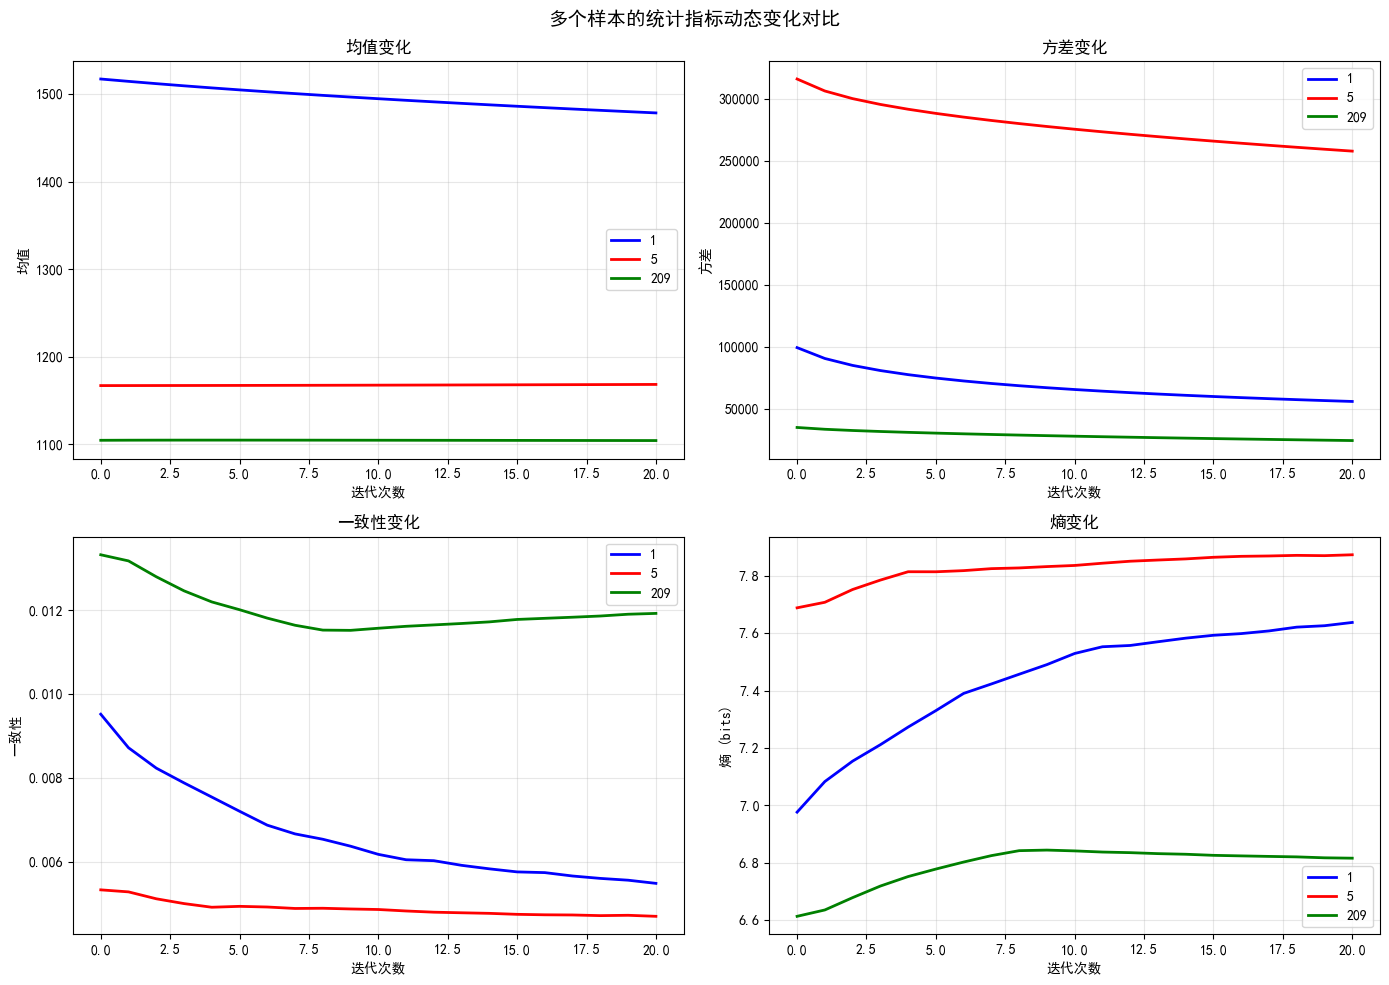

In [12]:
# 对三个样本比较统计指标变化
compare_samples = ['1.mat', '5.mat', '209.mat']
max_iter = 20

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['blue', 'red', 'green']

for s_idx, fname in enumerate(compare_samples):
    d = all_data[fname]
    img = d['image'].copy()
    mask = d['mask']

    # 记录迭代统计
    iters, means, vars_, unifs, ents = [], [], [], [], []
    for t in range(max_iter + 1):
        roi = img[mask > 0]
        m, v, u, e = compute_histogram_features(roi)
        iters.append(t)
        means.append(m)
        vars_.append(v)
        unifs.append(u)
        ents.append(e)
        if t < max_iter:
            img = mean_filter_3x3(img)

    color = colors[s_idx]
    label_short = fname.replace('.mat', '')

    axes[0, 0].plot(iters, means, '-', color=color, linewidth=2, label=label_short)
    axes[0, 1].plot(iters, vars_, '-', color=color, linewidth=2, label=label_short)
    axes[1, 0].plot(iters, unifs, '-', color=color, linewidth=2, label=label_short)
    axes[1, 1].plot(iters, ents, '-', color=color, linewidth=2, label=label_short)

axes[0, 0].set_title('均值变化', fontsize=12)
axes[0, 0].set_xlabel('迭代次数')
axes[0, 0].set_ylabel('均值')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].set_title('方差变化', fontsize=12)
axes[0, 1].set_xlabel('迭代次数')
axes[0, 1].set_ylabel('方差')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].set_title('一致性变化', fontsize=12)
axes[1, 0].set_xlabel('迭代次数')
axes[1, 0].set_ylabel('一致性')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].set_title('熵变化', fontsize=12)
axes[1, 1].set_xlabel('迭代次数')
axes[1, 1].set_ylabel('熵 (bits)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.suptitle('多个样本的统计指标动态变化对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.7 整幅图像的迭代均值滤波(可选)

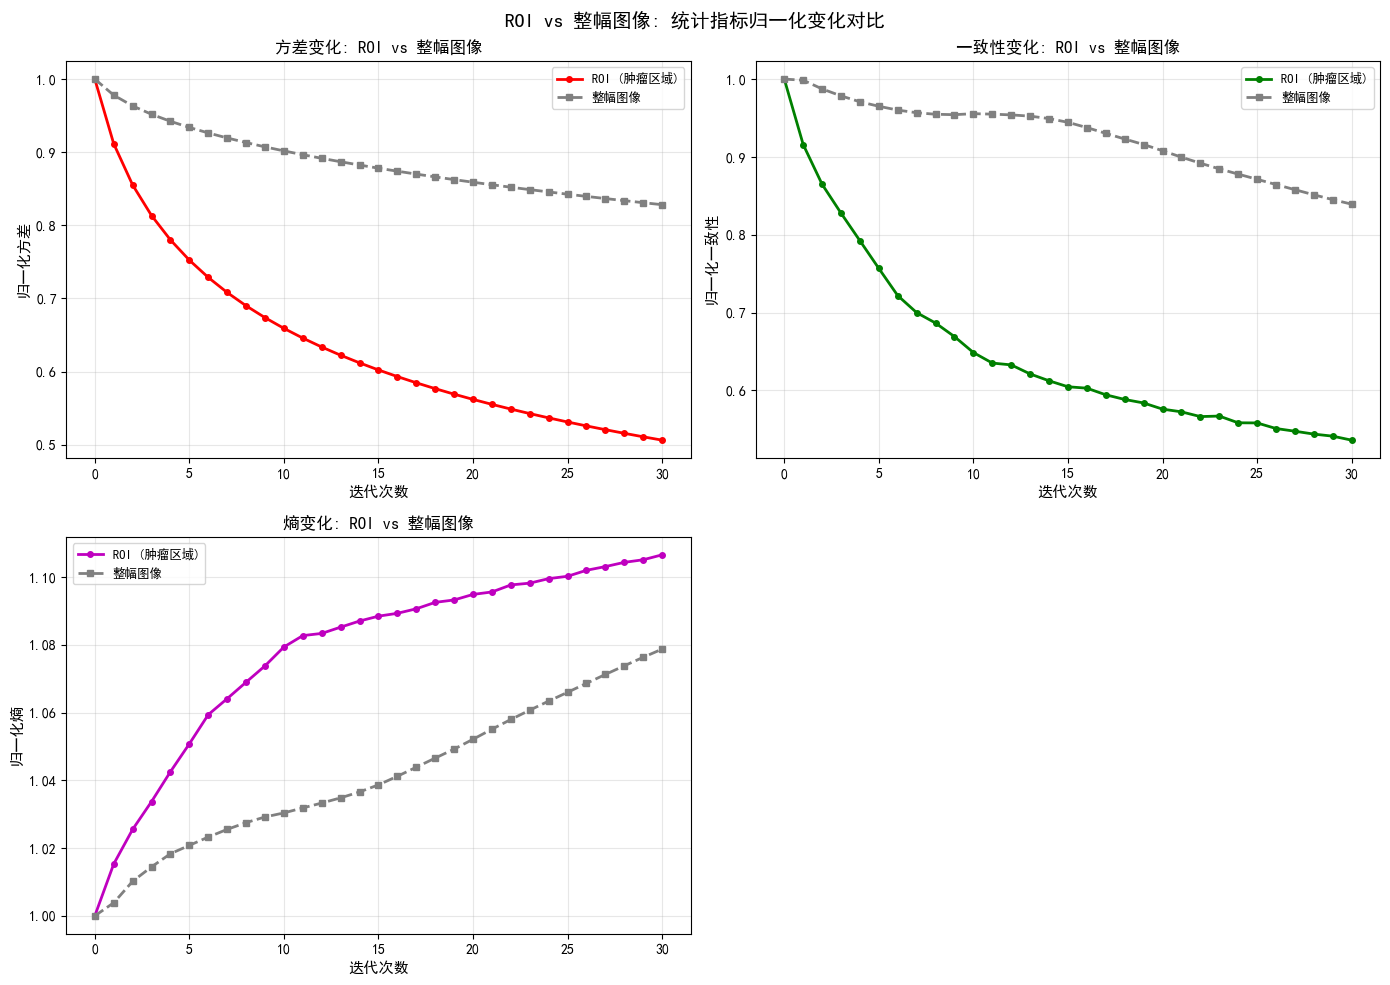

观察:
- ROI和全图的统计指标变化趋势相似
- 但ROI(仅肿瘤组织)的变化可能更快或更慢,取决于组织均匀性
- 全图包含背景(黑色区域),导致整体统计特征不同


In [13]:
# 在整幅图像上应用迭代均值滤波
sample_fname = '1.mat'
d = all_data[sample_fname]
full_img = d['image'].copy()

max_iter = 30
full_stats = {'iteration': [], 'mean': [], 'variance': [], 'uniformity': [], 'entropy': []}

for t in range(max_iter + 1):
    m, v, u, e = compute_histogram_features(full_img.flatten())
    full_stats['iteration'].append(t)
    full_stats['mean'].append(m)
    full_stats['variance'].append(v)
    full_stats['uniformity'].append(u)
    full_stats['entropy'].append(e)
    if t < max_iter:
        full_img = mean_filter_3x3(full_img)

# ROI vs 全图对比
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
labels = [('variance', '方差', 'r'), ('uniformity', '一致性', 'g'), ('entropy', '熵', 'm')]

for idx, (key, title, color) in enumerate(labels):
    ax = axes[idx // 2, idx % 2]
    # ROI数据
    roi_vals = np.array(roi_stats[key])
    full_vals = np.array(full_stats[key])

    ax.plot(roi_stats['iteration'], roi_vals / roi_vals[0],
            'o-', color=color, linewidth=2, markersize=4, label='ROI (肿瘤区域)')
    ax.plot(full_stats['iteration'], full_vals / full_vals[0],
            's--', color='gray', linewidth=2, markersize=4, label='整幅图像')
    ax.set_xlabel('迭代次数', fontsize=11)
    ax.set_ylabel(f'归一化{title}', fontsize=11)
    ax.set_title(f'{title}变化: ROI vs 整幅图像', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[1, 1].axis('off')  # 空位
plt.suptitle('ROI vs 整幅图像: 统计指标归一化变化对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("观察:")
print("- ROI和全图的统计指标变化趋势相似")
print("- 但ROI(仅肿瘤组织)的变化可能更快或更慢,取决于组织均匀性")
print("- 全图包含背景(黑色区域),导致整体统计特征不同")

### 讨论
**统计指标的动态变化规律:**

1. **均值 (Mean) 保持不变:** 3x3均值滤波器是一个线性、保持均值的操作。在理论上,均值在滤波过程中严格不变。实际计算中的微小波动来自边界处理。

2. **方差 (Variance) 单调递减:** 每次迭代通过平均相邻像素降低局部差异,方差逐渐减小。这与高斯模糊的方差增加效应一致 — 空间域平滑对应频域低通滤波。

3. **一致性 (Uniformity) 单调递增:** 随着图像变得平滑,灰度分布向均值集中,直方图变窄变高,一致性增加。极限情况下(无限次迭代),所有像素趋向相同值,一致性趋于1。

4. **熵 (Entropy) 单调递减:** 平滑减少了灰度级的变化,信息量降低。灰度级别减少意味着熵降低。

5. **渐进高斯行为:** 根据中心极限定理,迭代应用3x3均值滤波器在极限情况下等价于高斯滤波。方差随迭代次数线性减少。

6. **收敛速率:** 统计指标的初始变化最快,随后逐渐放缓,呈指数型收敛趋势。

# 项目3: 纹理特征与GLCM分析
### 原理

**灰度共生矩阵 (Gray Level Co-occurrence Matrix, GLCM)** 是描述图像纹理的强大工具。
它统计在给定空间关系 (距离d, 角度θ) 下,灰度级对 (i, j) 共同出现的频率。

对于量化到 G 个灰度级的图像,GLCM 是一个 GxG 的矩阵:
$$P(i, j | d, \theta) = \#\{(x,y) | I(x,y)=i, I(x+\Delta x, y+\Delta y)=j\}$$

其中 $\Delta x = d\cos\theta, \Delta y = d\sin\theta$

**Haralick特征:**
- **对比度 (Contrast):** 度量局部灰度变化
- **相关性 (Correlation):** 度量灰度级的线性依赖
- **能量 (Energy):** GLCM的均匀性(二阶一致性)
- **同质性 (Homogeneity):** 度量灰度级的局部相似性

### 步骤
1. 量化肿瘤ROI图像
2. 计算不同(d, θ)下的GLCM
3. 提取二阶统计特征
4. 研究采样步长与纹理的相互作用

### 3.1 图像量化与GLCM计算

样本 1.mat: ROI量化到 16 级
量化后有效像素数: 4569
GLCM(水平) 形状: (16, 16), 非零元素: 85
GLCM(垂直) 形状: (16, 16), 非零元素: 79
GLCM(水平) 总和: 1.0000


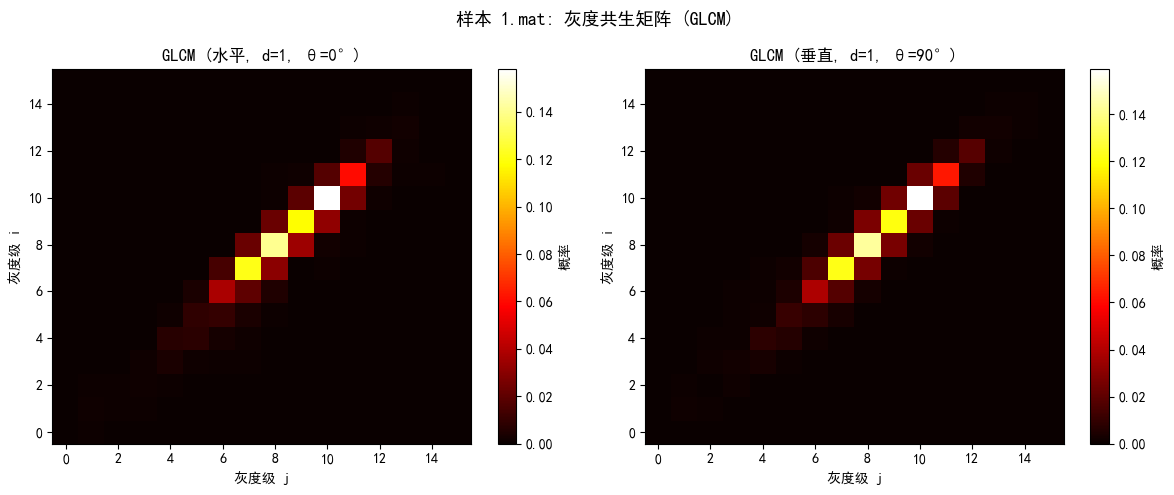


观察: GLCM中对角线附近的亮区表示相邻像素灰度级相似(平滑纹理),
远离对角线的亮区表示灰度突变(粗糙纹理或边缘)。


In [22]:
def quantize_image(image, mask, levels=16):
    """
    将ROI图像量化为指定灰度级数。

    参数:
        image: 原始图像
        mask: ROI掩膜
        levels: 目标灰度级数 (如 8, 16, 32, 64)

    返回:
        quantized: 量化后的图像(非ROI区域为-1)
    """
    roi_pixels = image[mask > 0]
    if len(roi_pixels) == 0:
        return np.full_like(image, -1, dtype=np.int32)

    p_min, p_max = roi_pixels.min(), roi_pixels.max()
    # 线性量化到 [0, levels-1]
    quantized = np.full_like(image, -1, dtype=np.int32)
    # 避免除零
    if p_max == p_min:
        quantized[mask > 0] = 0
    else:
        scaled = ((image[mask > 0].astype(np.float64) - p_min) / (p_max - p_min)
                  * (levels - 1))
        quantized[mask > 0] = np.clip(np.round(scaled).astype(np.int32), 0, levels - 1)

    return quantized

def compute_glcm(quantized_img, mask, distance=1, angle=0, levels=16):
    """
    计算灰度共生矩阵 (GLCM)。

    参数:
        quantized_img: 量化图像(非ROI为-1)
        mask: ROI掩膜
        distance: 采样距离 d
        angle: 采样角度 θ (弧度)
        levels: 灰度级数

    返回:
        glcm: 归一化的 GxG 共生矩阵
    """
    glcm = np.zeros((levels, levels), dtype=np.float64)

    # 计算偏移量
    dx = int(round(distance * np.cos(angle)))
    dy = int(round(distance * np.sin(angle)))

    # 获取ROI坐标
    rows, cols = np.where(mask > 0)

    for r, c in zip(rows, cols):
        r2 = r + dy
        c2 = c + dx
        # 检查目标像素是否在ROI内
        if 0 <= r2 < mask.shape[0] and 0 <= c2 < mask.shape[1] and mask[r2, c2] > 0:
            i = quantized_img[r, c]
            j = quantized_img[r2, c2]
            if i >= 0 and j >= 0:
                glcm[i, j] += 1

    # 归一化
    total = glcm.sum()
    if total > 0:
        glcm /= total

    return glcm

# 测试GLCM计算
sample_fname = '1.mat'
d = all_data[sample_fname]
levels = 16

quantized = quantize_image(d['image'], d['mask'], levels=levels)

# 计算两个不同方向的GLCM
glcm_h = compute_glcm(quantized, d['mask'], distance=1, angle=0, levels=levels)  # 水平
glcm_v = compute_glcm(quantized, d['mask'], distance=1, angle=np.pi/2, levels=levels)  # 垂直

print(f"样本 {sample_fname}: ROI量化到 {levels} 级")
print(f"量化后有效像素数: {(quantized >= 0).sum()}")
print(f"GLCM(水平) 形状: {glcm_h.shape}, 非零元素: {(glcm_h > 0).sum()}")
print(f"GLCM(垂直) 形状: {glcm_v.shape}, 非零元素: {(glcm_v > 0).sum()}")
print(f"GLCM(水平) 总和: {glcm_h.sum():.4f}")

# 可视化GLCM
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im1 = axes[0].imshow(glcm_h, cmap='hot', aspect='auto', origin='lower')
axes[0].set_title(f'GLCM (水平, d=1, θ=0°)', fontsize=12)
axes[0].set_xlabel('灰度级 j')
axes[0].set_ylabel('灰度级 i')
plt.colorbar(im1, ax=axes[0], label='概率')

im2 = axes[1].imshow(glcm_v, cmap='hot', aspect='auto', origin='lower')
axes[1].set_title(f'GLCM (垂直, d=1, θ=90°)', fontsize=12)
axes[1].set_xlabel('灰度级 j')
axes[1].set_ylabel('灰度级 i')
plt.colorbar(im2, ax=axes[1], label='概率')

plt.suptitle(f'样本 {sample_fname}: 灰度共生矩阵 (GLCM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n观察: GLCM中对角线附近的亮区表示相邻像素灰度级相似(平滑纹理),")
print("远离对角线的亮区表示灰度突变(粗糙纹理或边缘)。")

### 3.2 Haralick纹理特征提取

In [15]:
def compute_glcm_features(glcm):
    """
    从GLCM计算Haralick纹理特征。

    参数:
        glcm: 归一化的GxG共生矩阵

    返回:
        dict: 包含 contrast, correlation, energy, homogeneity
    """
    G = glcm.shape[0]
    i, j = np.mgrid[0:G, 0:G]

    # 对比度 (Contrast): sum((i-j)^2 * P(i,j))
    contrast = np.sum(((i - j) ** 2) * glcm)

    # 能量 (Energy) / 角二阶矩 (Angular Second Moment): sum(P(i,j)^2)
    energy = np.sum(glcm ** 2)

    # 同质性 (Homogeneity) / 逆差矩 (Inverse Difference Moment): sum(P(i,j) / (1+|i-j|))
    homogeneity = np.sum(glcm / (1.0 + np.abs(i - j)))

    # 相关性 (Correlation): sum((i-μi)(j-μj)*P(i,j)) / (σi*σj)
    mu_i = np.sum(i * glcm)
    mu_j = np.sum(j * glcm)
    sigma_i = np.sqrt(np.sum(((i - mu_i) ** 2) * glcm))
    sigma_j = np.sqrt(np.sum(((j - mu_j) ** 2) * glcm))

    if sigma_i > 0 and sigma_j > 0:
        correlation = np.sum(((i - mu_i) * (j - mu_j)) * glcm) / (sigma_i * sigma_j)
    else:
        correlation = 0.0

    return {
        'contrast': contrast,
        'correlation': correlation,
        'energy': energy,
        'homogeneity': homogeneity
    }

# 对所有样本计算GLCM特征
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
angle_names = ['0°', '45°', '90°', '135°']
levels = 16

print("=" * 90)
print(f"{"样本":<10} {"方向":<8} {"对比度":>10} {"相关性":>10} {"能量":>10} {"同质性":>10}")
print("-" * 90)

all_glcm_features = {}
for fname in data_files:
    d = all_data[fname]
    quantized = quantize_image(d['image'], d['mask'], levels=levels)
    all_glcm_features[fname] = {}

    for angle, angle_name in zip(angles, angle_names):
        glcm = compute_glcm(quantized, d['mask'], distance=1, angle=angle, levels=levels)
        feats = compute_glcm_features(glcm)
        all_glcm_features[fname][angle_name] = feats
        if angle_name == '0°':  # 每个样本只打印一次
            print(f"{fname:<10} {angle_name:<8} {feats["contrast"]:>10.4f} "
                  f"{feats["correlation"]:>10.4f} {feats["energy"]:>10.4f} "
                  f"{feats["homogeneity"]:>10.4f}")
        else:
            print(f"{"":<10} {angle_name:<8} {feats["contrast"]:>10.4f} "
                  f"{feats["correlation"]:>10.4f} {feats["energy"]:>10.4f} "
                  f"{feats["homogeneity"]:>10.4f}")
    print("-" * 90)

# 平均各方向特征
print("\n各样本的方向平均特征:")
print(f"{"样本":<10} {"标签":<6} {"对比度":>10} {"相关性":>10} {"能量":>10} {"同质性":>10}")
for fname in data_files:
    d = all_data[fname]
    avg_feats = {}
    for key in ['contrast', 'correlation', 'energy', 'homogeneity']:
        avg_feats[key] = np.mean([all_glcm_features[fname][a][key] for a in angle_names])
    label_name = "脑膜瘤" if d["label"] == 1 else "胶质瘤"
    print(f"{fname:<10} {label_name:<6} {avg_feats["contrast"]:>10.4f} "
          f"{avg_feats["correlation"]:>10.4f} {avg_feats["energy"]:>10.4f} "
          f"{avg_feats["homogeneity"]:>10.4f}")

样本         方向              对比度        相关性         能量        同质性
------------------------------------------------------------------------------------------
1.mat      0°           0.4904     0.9362     0.0851     0.8309
           45°          0.7872     0.8949     0.0764     0.7982
           90°          0.4214     0.9440     0.0871     0.8416
           135°         0.6895     0.9096     0.0704     0.7896
------------------------------------------------------------------------------------------
2.mat      0°           0.6557     0.9463     0.0512     0.7862
           45°          1.0264     0.9161     0.0430     0.7391
           90°          0.4792     0.9606     0.0585     0.8211
           135°         0.8228     0.9319     0.0461     0.7601
------------------------------------------------------------------------------------------
3.mat      0°           0.6742     0.9233     0.0731     0.7965
           45°          1.0666     0.8747     0.0633     0.7508
           90°         

### 3.3 特征可视化 — 不同方向的GLCM特征

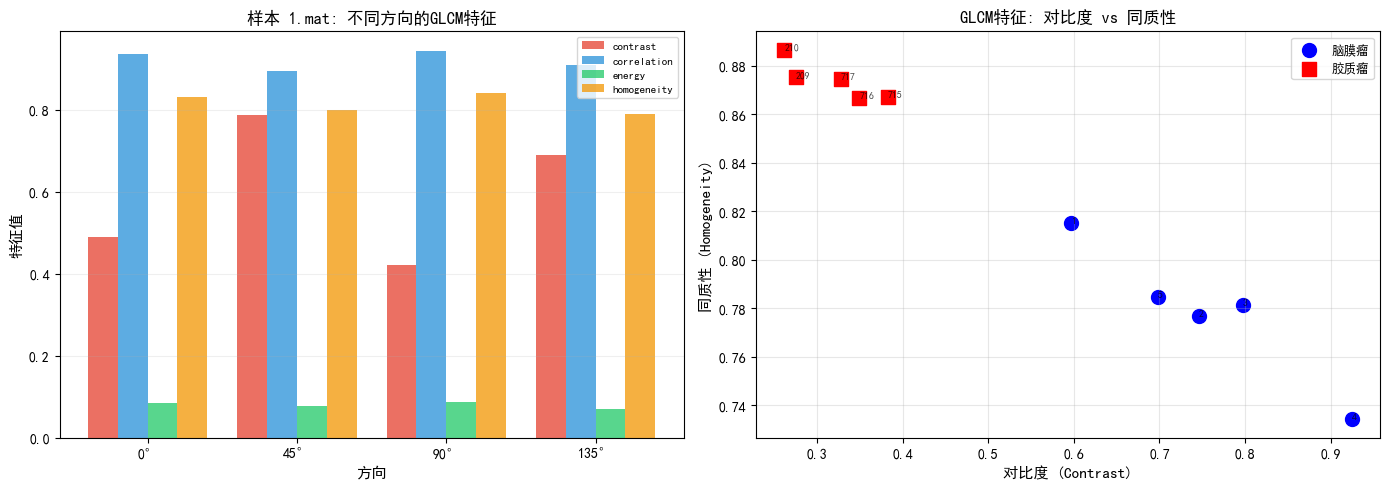

观察:
- 对比度高 + 同质性低 -> 纹理较粗糙(灰度变化大)
- 对比度低 + 同质性高 -> 纹理较平滑均匀
- 脑膜瘤与胶质瘤在某些特征空间可能表现不同


In [16]:
# 雷达图比较不同方向特征
sample_fname = '1.mat'
feats_by_angle = all_glcm_features[sample_fname]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 条形图比较
x = np.arange(len(angles))
width = 0.2
features_list = ['contrast', 'correlation', 'energy', 'homogeneity']
colors_bar = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, (feat, color) in enumerate(zip(features_list, colors_bar)):
    values = [feats_by_angle[a][feat] for a in angle_names]
    axes[0].bar(x + i * width, values, width, color=color, alpha=0.8, label=feat)

axes[0].set_xlabel('方向', fontsize=11)
axes[0].set_ylabel('特征值', fontsize=11)
axes[0].set_title(f'样本 {sample_fname}: 不同方向的GLCM特征', fontsize=12)
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(angle_names)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.2, axis='y')

# 特征分布散点图 (肿瘤类型比较)
# 对比度 vs 同质性
axes[1].set_title('GLCM特征: 对比度 vs 同质性', fontsize=12)
for fname in data_files:
    d = all_data[fname]
    avg_contrast = np.mean([all_glcm_features[fname][a]['contrast'] for a in angle_names])
    avg_homog = np.mean([all_glcm_features[fname][a]['homogeneity'] for a in angle_names])
    color = 'blue' if d['label'] == 1 else 'red'
    marker = 'o' if d['label'] == 1 else 's'
    label = '脑膜瘤' if d['label'] == 1 else '胶质瘤'
    axes[1].scatter(avg_contrast, avg_homog, c=color, marker=marker,
                   s=100, label=label if fname == '1.mat' or fname == '209.mat' else '')
    axes[1].annotate(fname.replace('.mat', ''), (avg_contrast, avg_homog),
                    fontsize=7, alpha=0.7)

axes[1].set_xlabel('对比度 (Contrast)', fontsize=11)
axes[1].set_ylabel('同质性 (Homogeneity)', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("观察:")
print("- 对比度高 + 同质性低 -> 纹理较粗糙(灰度变化大)")
print("- 对比度低 + 同质性高 -> 纹理较平滑均匀")
print("- 脑膜瘤与胶质瘤在某些特征空间可能表现不同")

### 3.4 采样步长 d 的影响 — 核心实验

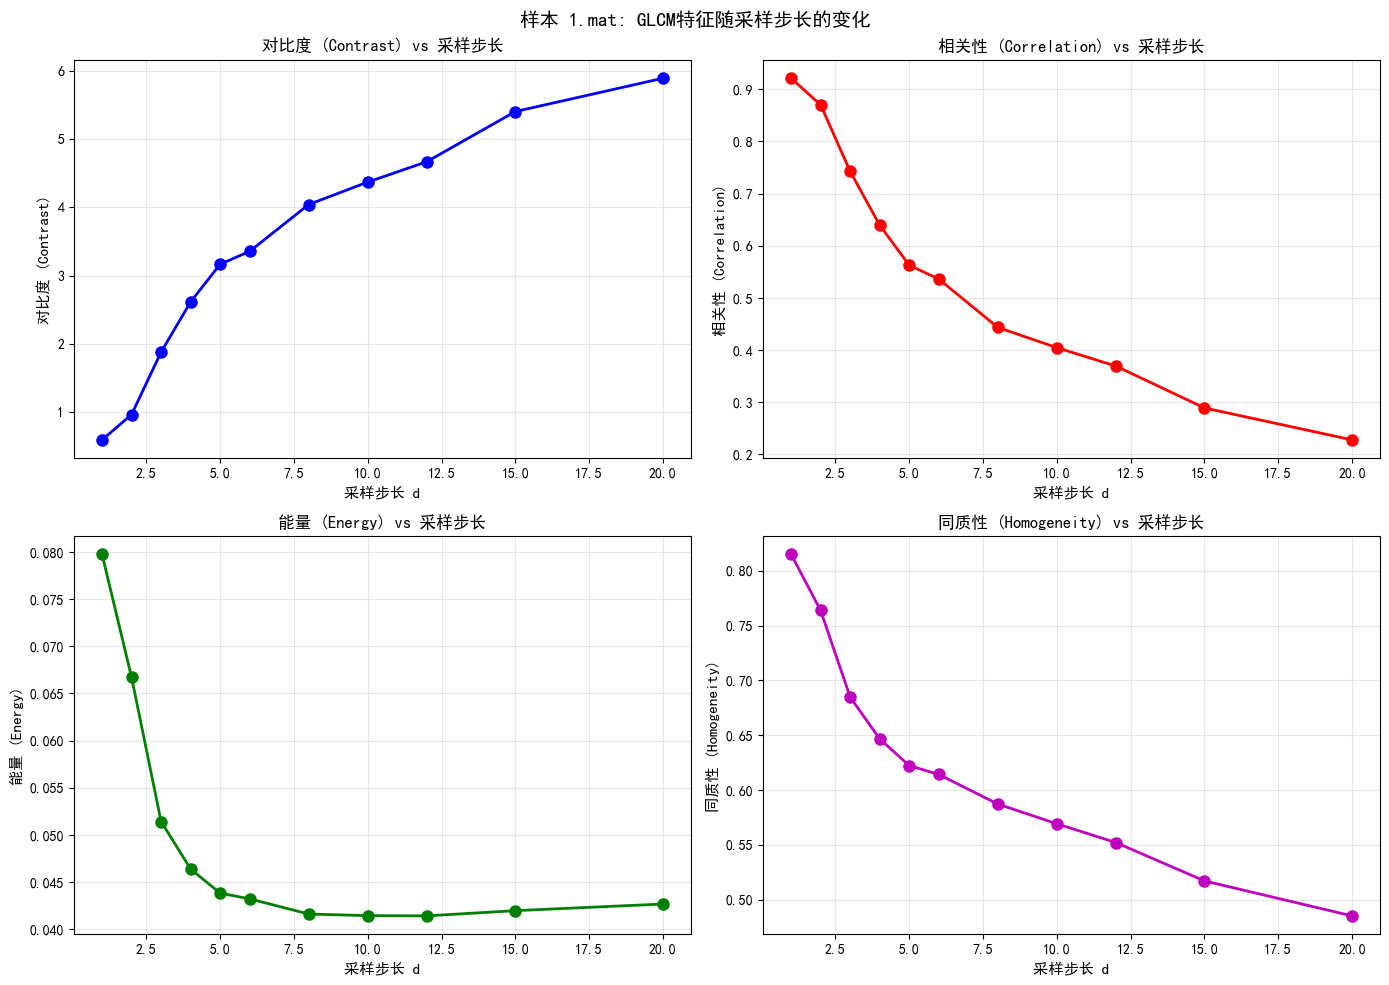

采样步长对GLCM特征的影响:

1. 对比度随d增大而增大: 远距离像素对更可能跨越纹理边界
2. 相关性随d增大而减小: 像素间灰度依赖随距离衰减
3. 能量随d增大而减小: 共生矩阵变得更分散
4. 同质性随d增大而减小: 远距离像素灰度差异更大


In [17]:
def compute_feature_vs_distance(image, mask, distances, levels=16):
    """计算不同采样步长下的GLCM特征"""
    quantized = quantize_image(image, mask, levels=levels)
    results = {d: [] for d in distances}

    for d in distances:
        # 四个方向的平均特征
        d_feats = []
        for angle in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
            glcm = compute_glcm(quantized, mask, distance=d, angle=angle, levels=levels)
            feats = compute_glcm_features(glcm)
            d_feats.append(feats)
        # 四个方向的平均
        avg = {}
        for key in ['contrast', 'correlation', 'energy', 'homogeneity']:
            avg[key] = np.mean([f[key] for f in d_feats])
        results[d] = avg

    return results

# 测试不同的采样距离
distances = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20]
sample_fname = '1.mat'
d = all_data[sample_fname]

dist_results = compute_feature_vs_distance(d['image'], d['mask'], distances, levels=16)

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

feature_configs = [
    ('contrast', '对比度 (Contrast)', 'b'),
    ('correlation', '相关性 (Correlation)', 'r'),
    ('energy', '能量 (Energy)', 'g'),
    ('homogeneity', '同质性 (Homogeneity)', 'm'),
]

for idx, (key, title, color) in enumerate(feature_configs):
    ax = axes[idx // 2, idx % 2]
    values = [dist_results[d][key] for d in distances]
    ax.plot(distances, values, 'o-', color=color, linewidth=2, markersize=8)
    ax.set_xlabel('采样步长 d', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} vs 采样步长', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'样本 {sample_fname}: GLCM特征随采样步长的变化', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 60)
print("采样步长对GLCM特征的影响:")
print()
print("1. 对比度随d增大而增大: 远距离像素对更可能跨越纹理边界")
print("2. 相关性随d增大而减小: 像素间灰度依赖随距离衰减")
print("3. 能量随d增大而减小: 共生矩阵变得更分散")
print("4. 同质性随d增大而减小: 远距离像素灰度差异更大")
print("=" * 60)

### 3.5 多距离GLCM可视化

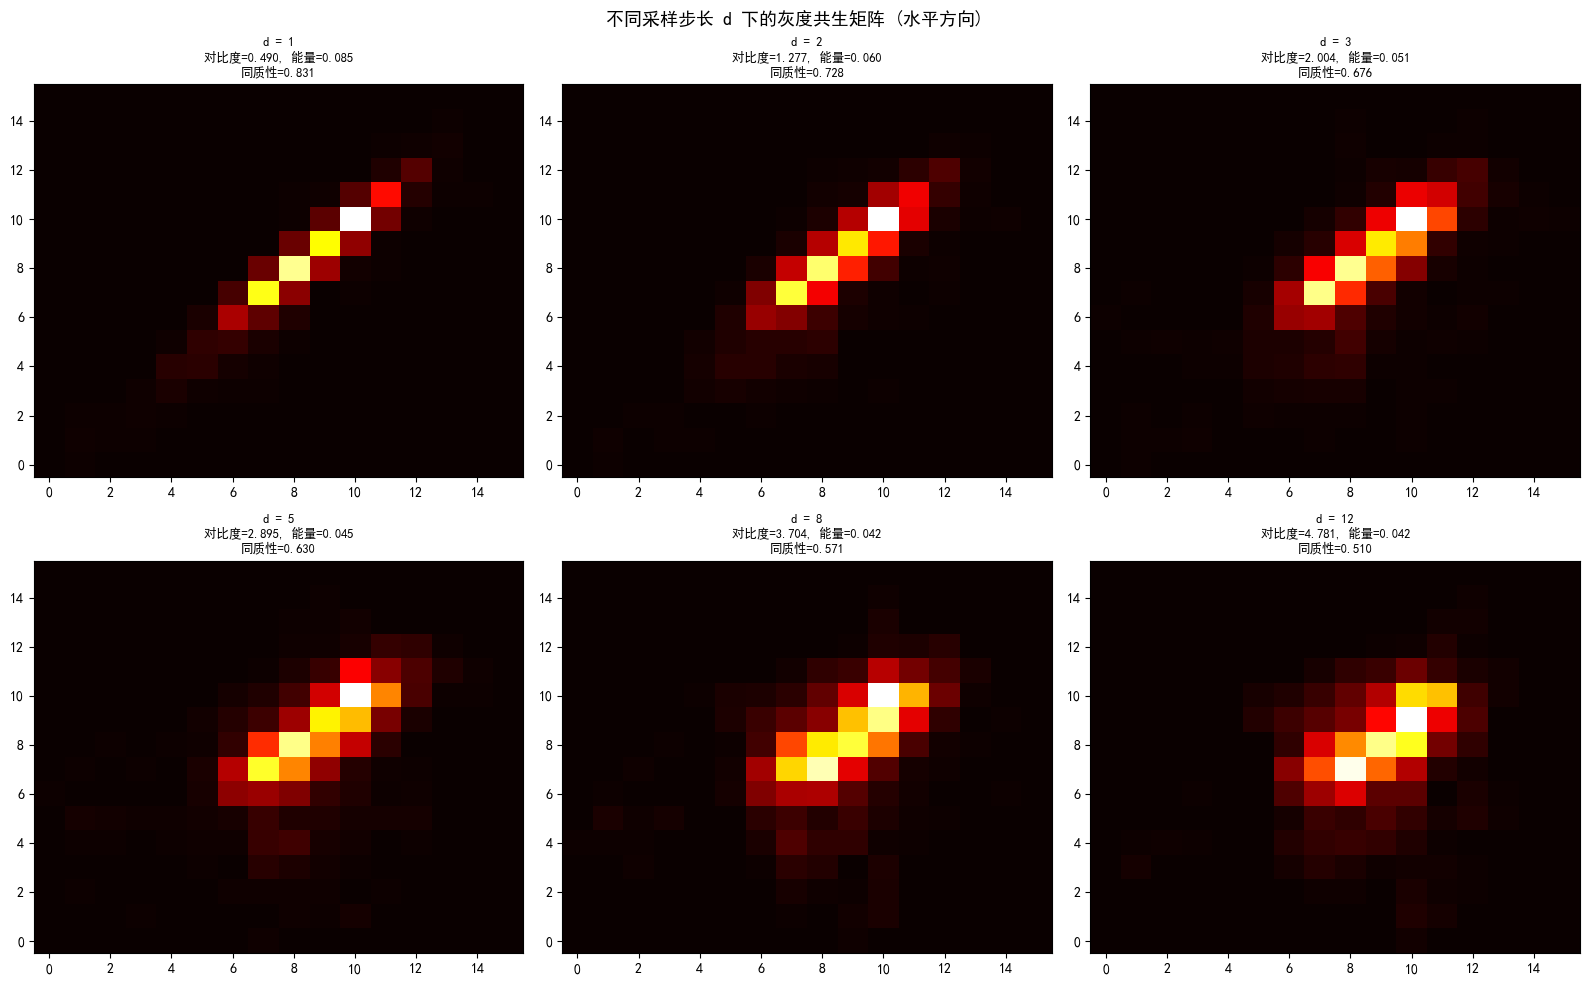

观察随着d增大的GLCM变化:
- d=1: 非零元素集中在对角线附近 -> 相邻像素灰度相似
- d增大: GLCM逐渐扩散,非对角线元素增加 -> 纹理粗糙度增大
- 如果存在周期性纹理,GLCM会在特定d处出现周期性模式


In [18]:
# 展示不同距离下的GLCM矩阵
sample_fname = '1.mat'
d = all_data[sample_fname]
levels = 16

distances_show = [1, 2, 3, 5, 8, 12]
quantized = quantize_image(d['image'], d['mask'], levels=levels)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, dist in enumerate(distances_show):
    glcm = compute_glcm(quantized, d['mask'], distance=dist, angle=0, levels=levels)
    feats = compute_glcm_features(glcm)

    axes[idx].imshow(glcm, cmap='hot', aspect='auto', origin='lower')
    axes[idx].set_title(f'd = {dist}\n对比度={feats["contrast"]:.3f}, '
                        f'能量={feats["energy"]:.3f}\n同质性={feats["homogeneity"]:.3f}',
                        fontsize=9)

plt.suptitle('不同采样步长 d 下的灰度共生矩阵 (水平方向)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("观察随着d增大的GLCM变化:")
print("- d=1: 非零元素集中在对角线附近 -> 相邻像素灰度相似")
print("- d增大: GLCM逐渐扩散,非对角线元素增加 -> 纹理粗糙度增大")
print("- 如果存在周期性纹理,GLCM会在特定d处出现周期性模式")

### 3.6 多个样本的距离-特征曲线对比

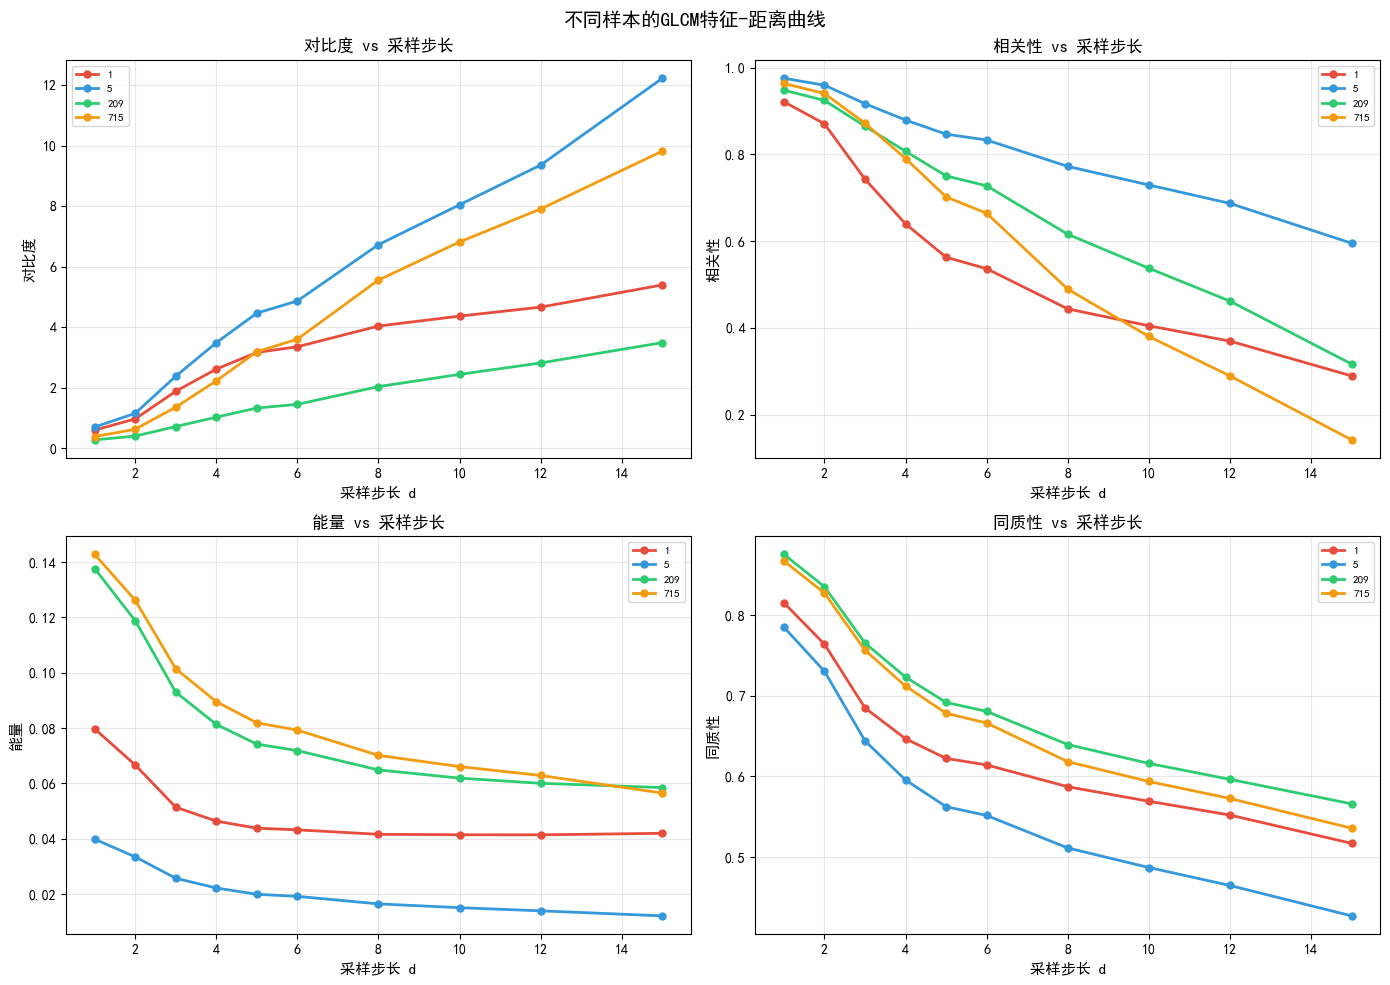

跨样本观察:
- 不同肿瘤的纹理特征曲线形状不同,反映其内部纹理结构的差异
- 对比度曲线在胶质瘤中通常更高 -> 更不均匀的内部纹理
- 相关性衰减速度反映纹理的'记忆长度' — 相关像素的空间范围


In [19]:
# 比较三个样本的对比度-距离曲线
compare_samples = ['1.mat', '5.mat', '209.mat', '715.mat']
distances = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
feature_keys = ['contrast', 'correlation', 'energy', 'homogeneity']
feature_titles = ['对比度', '相关性', '能量', '同质性']

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for f_idx, fname in enumerate(compare_samples):
    d = all_data[fname]
    dist_results = compute_feature_vs_distance(d['image'], d['mask'], distances, levels=16)

    for ax_idx, (key, title) in enumerate(zip(feature_keys, feature_titles)):
        ax = axes[ax_idx // 2, ax_idx % 2]
        values = [dist_results[dist][key] for dist in distances]
        ax.plot(distances, values, 'o-', color=colors[f_idx], linewidth=2,
               markersize=5, label=fname.replace('.mat', ''))

for ax_idx, (key, title) in enumerate(zip(feature_keys, feature_titles)):
    ax = axes[ax_idx // 2, ax_idx % 2]
    ax.set_xlabel('采样步长 d', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} vs 采样步长', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('不同样本的GLCM特征-距离曲线', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("跨样本观察:")
print("- 不同肿瘤的纹理特征曲线形状不同,反映其内部纹理结构的差异")
print("- 对比度曲线在胶质瘤中通常更高 -> 更不均匀的内部纹理")
print("- 相关性衰减速度反映纹理的'记忆长度' — 相关像素的空间范围")

### 3.7 采样步长与周期性结构纹理的相互作用

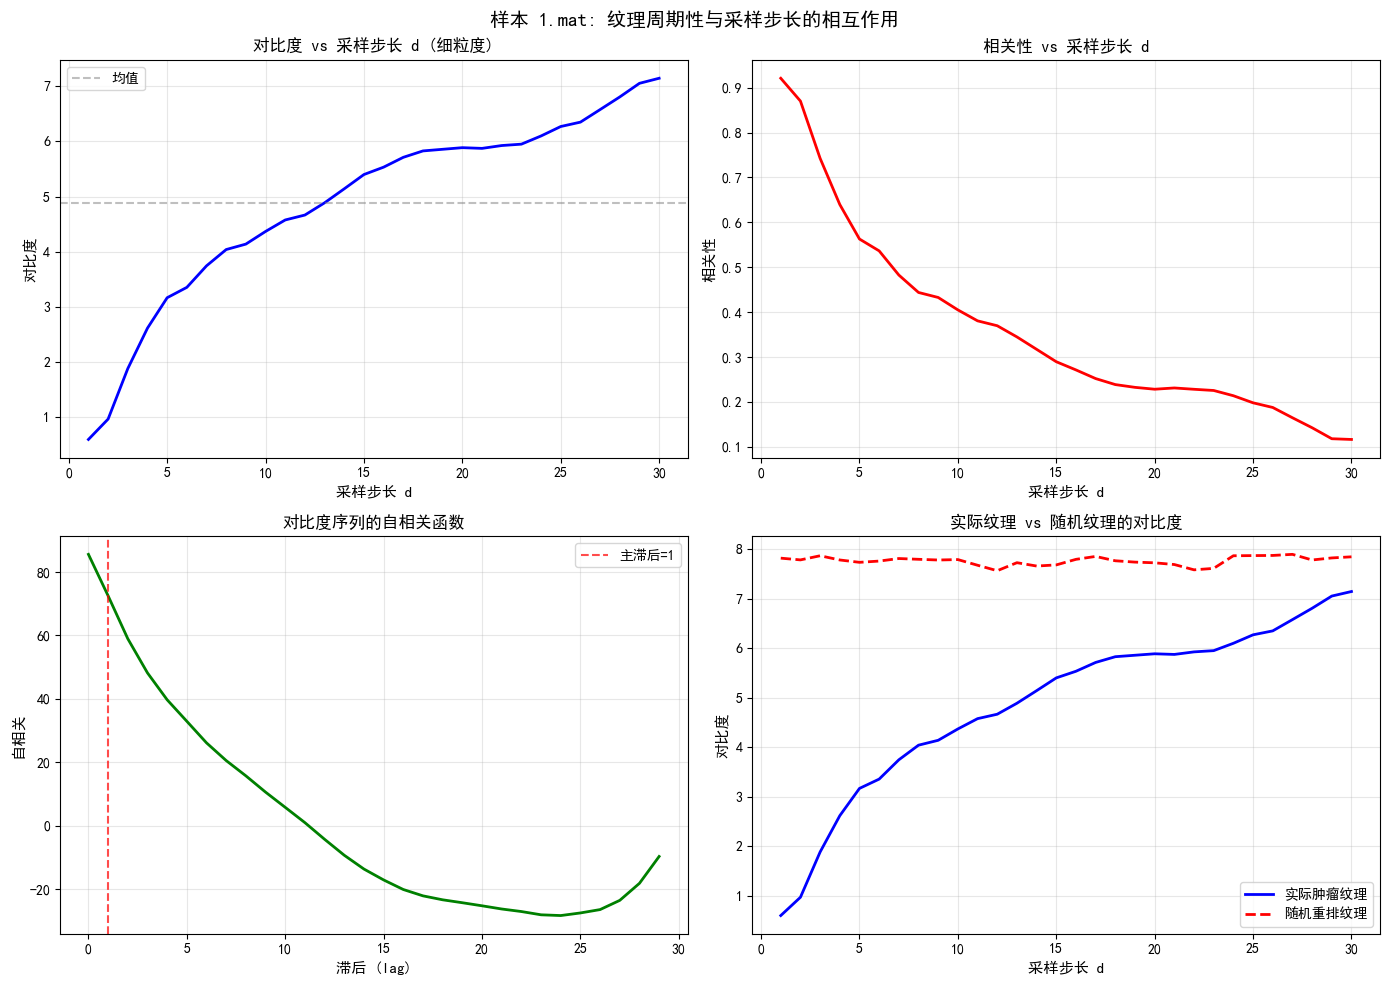

采样步长与周期性纹理的相互作用:

1. 如果纹理具有周期性结构,GLCM特征在d=周期长度时
   会出现特征性的波动或拐点
2. 自相关函数可以检测这种周期性 — 主峰位置对应主导纹理尺度
3. 实际肿瘤纹理 vs 随机纹理的对比度差异:
   - 实际纹理: 特征随d呈现结构性变化
   - 随机纹理: 特征变化较平缓,缺少结构
4. GLCM本质上探测的是像素间的空间依赖关系 —
   当采样步长匹配纹理的特征尺度时会产生共振效应


In [20]:
# 研究周期性: 在更大的距离范围内观察特征变化
sample_fname = '1.mat'
d = all_data[sample_fname]
distances_fine = list(range(1, 31))  # 1到30的细粒度采样

dist_results_fine = compute_feature_vs_distance(d['image'], d['mask'], distances_fine, levels=16)

# 提取特征序列
contrast_seq = np.array([dist_results_fine[dist]['contrast'] for dist in distances_fine])
correlation_seq = np.array([dist_results_fine[dist]['correlation'] for dist in distances_fine])

# 特征序列的自相关分析(检测周期性)
def autocorrelation(x):
    """计算自相关函数"""
    x = x - np.mean(x)
    result = np.correlate(x, x, mode='full')
    return result[result.size // 2:]

contrast_acf = autocorrelation(contrast_seq)

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 对比度 vs 距离
axes[0, 0].plot(distances_fine, contrast_seq, 'b-', linewidth=2)
axes[0, 0].set_xlabel('采样步长 d', fontsize=11)
axes[0, 0].set_ylabel('对比度', fontsize=11)
axes[0, 0].set_title('对比度 vs 采样步长 d (细粒度)', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
# 标注可能的周期特征
axes[0, 0].axhline(y=np.mean(contrast_seq), color='gray', linestyle='--', alpha=0.5, label='均值')
axes[0, 0].legend()

# 相关性 vs 距离
axes[0, 1].plot(distances_fine, correlation_seq, 'r-', linewidth=2)
axes[0, 1].set_xlabel('采样步长 d', fontsize=11)
axes[0, 1].set_ylabel('相关性', fontsize=11)
axes[0, 1].set_title('相关性 vs 采样步长 d', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# 自相关分析
axes[1, 0].plot(range(len(contrast_acf)), contrast_acf, 'g-', linewidth=2)
axes[1, 0].set_xlabel('滞后 (lag)', fontsize=11)
axes[1, 0].set_ylabel('自相关', fontsize=11)
axes[1, 0].set_title('对比度序列的自相关函数', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
# 标注主峰
peak_idx = np.argmax(contrast_acf[1:]) + 1
if peak_idx < len(contrast_acf) - 1:
    axes[1, 0].axvline(x=peak_idx, color='r', linestyle='--', alpha=0.7,
                      label=f'主滞后={peak_idx}')
    axes[1, 0].legend()

# 对比: 随机纹理 vs 实际肿瘤纹理
# 生成随机纹理(打乱像素位置)进行比较
roi_pixels = d['image'][d['mask'] > 0].copy()
np.random.shuffle(roi_pixels)
shuffled_image = d['image'].copy()
shuffled_image[d['mask'] > 0] = roi_pixels

shuffled_results = compute_feature_vs_distance(shuffled_image, d['mask'], distances_fine, levels=16)
shuffled_contrast = [shuffled_results[dist]['contrast'] for dist in distances_fine]

axes[1, 1].plot(distances_fine, contrast_seq, 'b-', linewidth=2, label='实际肿瘤纹理')
axes[1, 1].plot(distances_fine, shuffled_contrast, 'r--', linewidth=2, label='随机重排纹理')
axes[1, 1].set_xlabel('采样步长 d', fontsize=11)
axes[1, 1].set_ylabel('对比度', fontsize=11)
axes[1, 1].set_title('实际纹理 vs 随机纹理的对比度', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'样本 {sample_fname}: 纹理周期性与采样步长的相互作用', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=" * 60)
print("采样步长与周期性纹理的相互作用:")
print()
print("1. 如果纹理具有周期性结构,GLCM特征在d=周期长度时")
print("   会出现特征性的波动或拐点")
print("2. 自相关函数可以检测这种周期性 — 主峰位置对应主导纹理尺度")
print("3. 实际肿瘤纹理 vs 随机纹理的对比度差异:")
print("   - 实际纹理: 特征随d呈现结构性变化")
print("   - 随机纹理: 特征变化较平缓,缺少结构")
print("4. GLCM本质上探测的是像素间的空间依赖关系 —")
print("   当采样步长匹配纹理的特征尺度时会产生共振效应")
print("=" * 60)

### 3.8 不同量化级数的影响

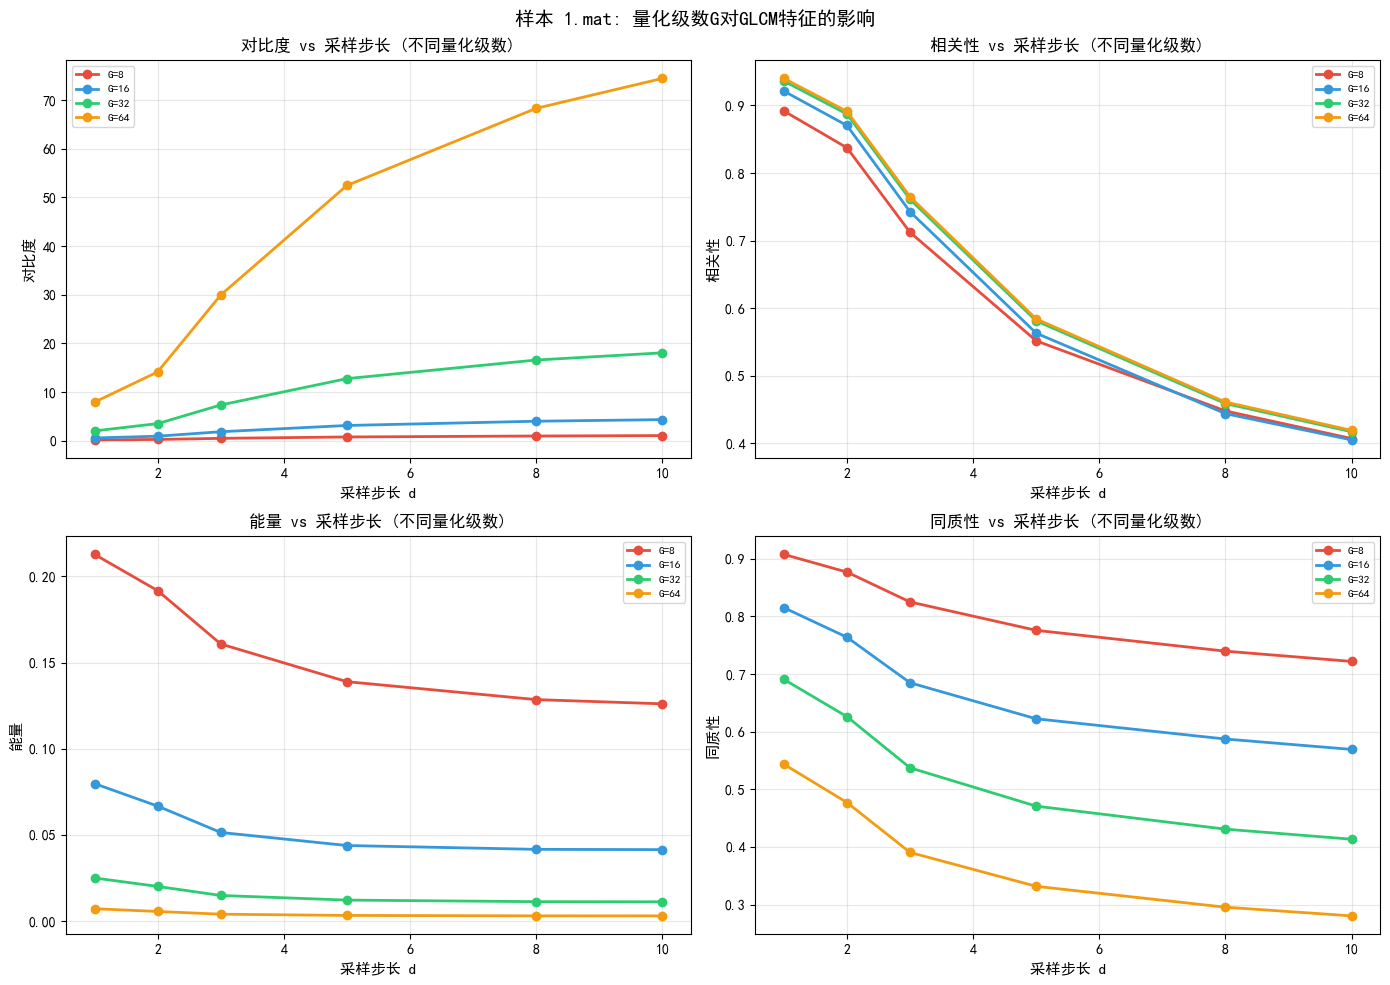

量化级数的影响:
- G越大: 灰度分辨率越高,GLCM更稀疏但保留了更多纹理细节
- G越小: 灰度合并越多,纹理信息被平滑,但统计更稳定
- 实用中常用 G=16 或 G=32 作为平衡点
- 能量特征对G最敏感: G增大时能量显著降低(GLCM更分散)


In [21]:
# 比较不同量化级别对GLCM特征的影响
sample_fname = '1.mat'
d = all_data[sample_fname]
level_options = [8, 16, 32, 64]
distances = [1, 2, 3, 5, 8, 10]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_lv = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for lv_idx, levels in enumerate(level_options):
    color = colors_lv[lv_idx]
    quantized = quantize_image(d['image'], d['mask'], levels=levels)

    for key, ax, title in [
        ('contrast', axes[0, 0], '对比度'),
        ('correlation', axes[0, 1], '相关性'),
        ('energy', axes[1, 0], '能量'),
        ('homogeneity', axes[1, 1], '同质性')
    ]:
        values = []
        for dist in distances:
            glcm_feats = []
            for angle in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
                glcm = compute_glcm(quantized, d['mask'], distance=dist, angle=angle, levels=levels)
                feats = compute_glcm_features(glcm)
                glcm_feats.append(feats[key])
            values.append(np.mean(glcm_feats))

        ax.plot(distances, values, 'o-', color=color, linewidth=2, markersize=6,
               label=f'G={levels}')

for ax, title in [
    (axes[0, 0], '对比度'),
    (axes[0, 1], '相关性'),
    (axes[1, 0], '能量'),
    (axes[1, 1], '同质性')
]:
    ax.set_xlabel('采样步长 d', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} vs 采样步长 (不同量化级数)', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'样本 {sample_fname}: 量化级数G对GLCM特征的影响', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("量化级数的影响:")
print("- G越大: 灰度分辨率越高,GLCM更稀疏但保留了更多纹理细节")
print("- G越小: 灰度合并越多,纹理信息被平滑,但统计更稳定")
print("- 实用中常用 G=16 或 G=32 作为平衡点")
print("- 能量特征对G最敏感: G增大时能量显著降低(GLCM更分散)")

### 讨论

**采样步长如何与周期性结构纹理相互作用:**

1. **短步长 (d小):** GLCM描述的是近邻像素关系,对微观纹理敏感。平滑纹理显示高对角能量,粗糙纹理显示扩散模式。

2. **步长匹配纹理周期:** 当采样步长 d 恰好匹配纹理的重复周期时,GLCM特征会出现特征性变化:
   - 对比度在周期整数倍处出现局部极小值(相似灰度再次相遇)
   - 相关性出现振荡,反映周期性依赖
   - 这种现象类似于自相关函数的峰值

3. **长步长 (d大):** 像素间的空间相关性衰减,GLCM趋向均匀分布,特征趋于稳定值。对比度趋于2σ²(独立像素的期望差异)。

4. **纹理方向性:** 各向异性纹理在不同角度产生不同的GLCM特征。沿纹理方向的GLCM更集中(低对比度),垂直于纹理方向的GLCM更分散(高对比度)。

5. **肿瘤纹理特征:** 恶性与良性肿瘤的纹理差异反映在GLCM特征上。恶性肿瘤通常具有更粗糙、更不均匀的内部纹理(更高的对比度和更低的同质性)。

6. **实际应用:** GLCM特征可作为肿瘤分类的输入特征,采样步长应覆盖感兴趣的纹理尺度范围(通常1-10像素)。